### Pronostico Baseline (LSTM) / Mejoramiento de Hiperparametros (Optune)


--- Resumen de Muestras ---
Total de muestras secuenciales: 52. Tren/Val/Test: 31/10/11.

--- 3. Baseline LSTM ---


C:\Users\Diego\anaconda3B\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2025-11-27 13:28:11,156] A new study created in memory with name: no-name-c4ce74e7-9556-4ea1-96fb-e95c1ae93d2a


RMSE Baseline (Prueba): 0.0923
Gráfico 'baseline_rmse_history.png' generado.

--- 4. Optimización de Hiperparámetros con Optuna ---


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2025-11-27 13:28:25,051] Trial 0 finished with value: 0.06764929741621017 and parameters: {'units': 90, 'learning_rate': 0.0010398267102932652, 'batch_size': 32}. Best is trial 0 with value: 0.06764929741621017.
[I 2025-11-27 13:28:36,084] Trial 1 finished with value: 0.06707718223333359 and parameters: {'units': 70, 'learning_rate': 0.0027359586544037254, 'batch_size': 16}. Best is trial 1 with value: 0.06707718223333359.
[I 2025-11-27 13:28:48,559] Trial 2 finished with value: 0.06901555508375168 and parameters: {'units': 90, 'learning_rate': 0.0004039527235196221, 'batch_size': 16}. Best is trial 1 with value: 0.06707718223333359.
[I 2025-11-27 13:29:05,348] Trial 3 finished with value: 0.6990198493003845 and parameters: {'units': 80, 'learning_rate': 0.00013301765576785785, 'batch_size': 32}. Best is trial 1 with value: 0.06707718223333359.
[I 2025-11-27 13:29:18,174] Trial 4 finished with value: 0.07498239725828171 and parameters: {'units': 70, 'learning_rate': 0.00076612178972

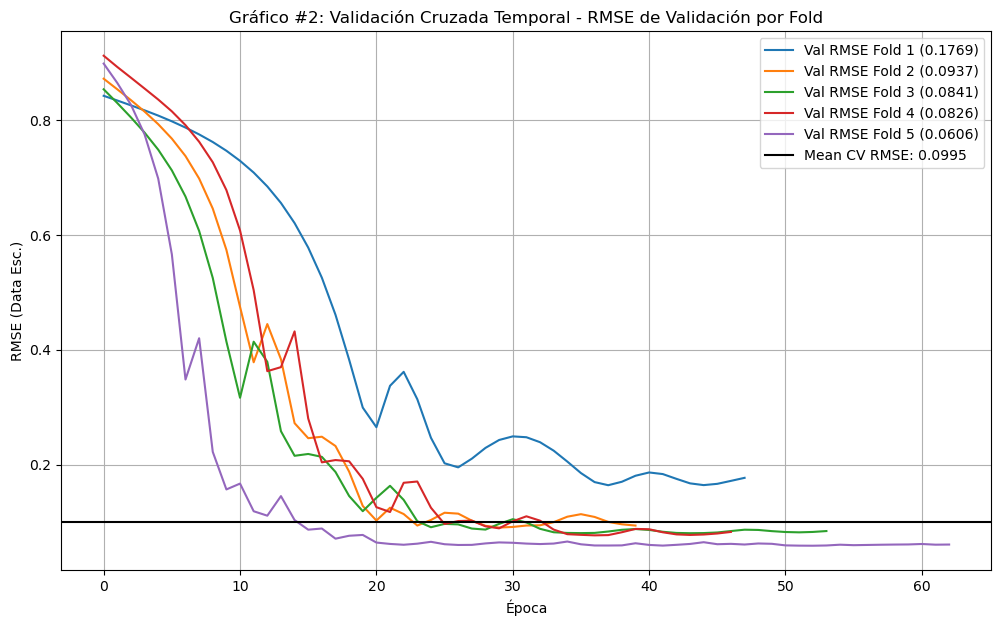

Gráfico 'ts_cross_validation_rmse.png' generado.

--- Tabla de Resultados de la Validación Cruzada ---
╒══════════╤═════════════════╤═════════════════╤═════════════╕
│ Fold     │ Muestras Tren   │ Muestras Test   │   Test RMSE │
╞══════════╪═════════════════╪═════════════════╪═════════════╡
│ 1        │ 11              │ 6               │      0.1769 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 2        │ 17              │ 6               │      0.0937 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 3        │ 23              │ 6               │      0.0841 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 4        │ 29              │ 6               │      0.0826 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 5        │ 35              │ 6               │      0.0606 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ Promedio │ -               │ -               │      0.0995 │
╘══════════╧═══

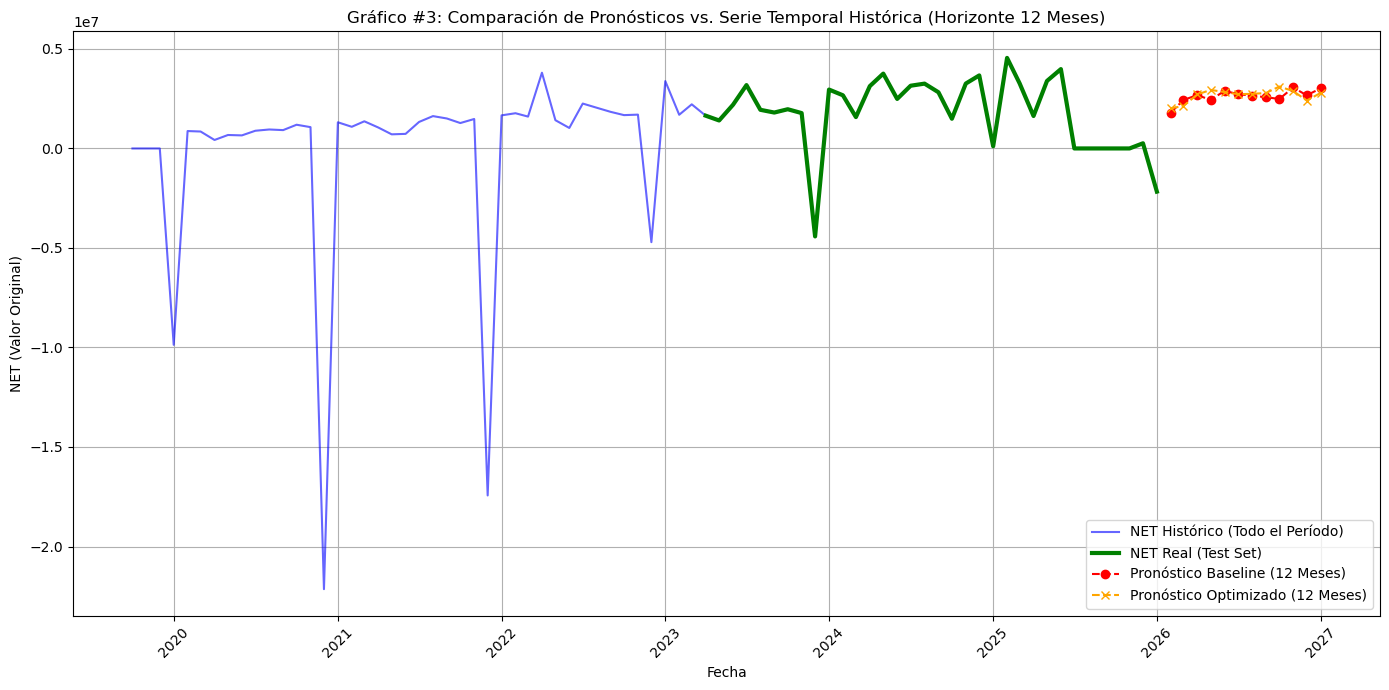

Gráfico 'final_forecast_comparison.png' generado.

--- Tabla de Pronósticos de 12 Meses (NET Original) ---
╒═════════╤════════════╤═══════════════════════╕
│ Mes     │   Baseline │   Optimizado (Optuna) │
╞═════════╪════════════╪═══════════════════════╡
│ 2026-02 │ 1798803.12 │            2022997.00 │
├─────────┼────────────┼───────────────────────┤
│ 2026-03 │ 2433418.75 │            2126484.25 │
├─────────┼────────────┼───────────────────────┤
│ 2026-04 │ 2679575.00 │            2711258.25 │
├─────────┼────────────┼───────────────────────┤
│ 2026-05 │ 2439986.25 │            2942191.75 │
├─────────┼────────────┼───────────────────────┤
│ 2026-06 │ 2892506.00 │            2831559.25 │
├─────────┼────────────┼───────────────────────┤
│ 2026-07 │ 2727392.75 │            2726417.50 │
├─────────┼────────────┼───────────────────────┤
│ 2026-08 │ 2654290.50 │            2743183.50 │
├─────────┼────────────┼───────────────────────┤
│ 2026-09 │ 2572945.50 │            2783986.50 │
├─────────┼

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from math import sqrt
from tabulate import tabulate # Usado para generar las tablas

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping

# --- 0. Parámetros Globales ---
FILE_PATH = '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv'
PORTFOLIO_NAME = 'L2-ALL'
DESCTYPE_FILTER_COLUMN = 'DESCTYPE'
DESCTYPE_FILTER_VALUE = 'Balance Sheet' 

LOOK_BACK = 12          # Ventana de entrada (12 meses)
FORECAST_HORIZON = 12   # Pronóstico de 12 meses
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20
N_SPLITS_CV = 5
N_TRIALS_OPTUNA = 15    # Ajustar a un número mayor (e.g., 50+) en producción
BASELINE_EPOCHS = 100
OPTIMIZED_EPOCHS = 100 

# --- 1. Funciones de Modelado y Data Preparation ---

def create_sequences(data, look_back, forecast_horizon):
    """Crea secuencias de entrada (X) y salida (y) para el modelo LSTM."""
    X, y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back : i + look_back + forecast_horizon, 0])
    X_reshaped = np.reshape(np.array(X), (len(X), look_back, 1))
    return X_reshaped, np.array(y)

def build_model(units, learning_rate):
    """Crea un modelo LSTM de Keras con hiperparámetros ajustables."""
    model = Sequential([
        LSTM(units, activation='relu', input_shape=(LOOK_BACK, 1)),
        Dense(FORECAST_HORIZON)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=[RootMeanSquaredError(name='rmse')])
    return model

# --- 2. Carga y Preparación de Datos ---

try:
    df = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{FILE_PATH}'. Asegúrese de que el archivo esté en el directorio correcto.")
    exit()

# Filtrar por PORTFOLIONAME y DESCTYPE
df_filtered = df[
    (df['PORTFOLIONAME'] == PORTFOLIO_NAME) & 
    (df[DESCTYPE_FILTER_COLUMN] == DESCTYPE_FILTER_VALUE)
].copy()

# Verificación de Datos Filtrados
if df_filtered.empty:
    print(f"Error Crítico: No se encontraron registros para PORTFOLIONAME='{PORTFOLIO_NAME}' y {DESCTYPE_FILTER_COLUMN}='{DESCTYPE_FILTER_VALUE}'.")
    exit()

# Crear índice de tiempo y agregar la serie de tiempo (suma mensual de NET)
df_filtered['DATE'] = pd.to_datetime(df_filtered['YEARID'].astype(str) + '-' + df_filtered['MONTHID'].astype(str) + '-01')
df_filtered['NET'] = df_filtered['NET'].fillna(0)
ts_data = df_filtered.groupby('DATE')['NET'].sum().sort_index()

# Escalar la data
data = ts_data.values.reshape(-1, 1)

# Verificación de Longitud de la Serie de Tiempo
min_required_steps = LOOK_BACK + FORECAST_HORIZON
if len(data) < min_required_steps:
    print(f"Error Crítico: La serie de tiempo mensual generada solo tiene {len(data)} puntos.")
    print(f"Se requieren al menos {min_required_steps} ({LOOK_BACK} lookback + {FORECAST_HORIZON} forecast) para crear las primeras secuencias.")
    exit()

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data) 

X, y = create_sequences(scaled_data, LOOK_BACK, FORECAST_HORIZON)

# División 60/20/20 (Secuencial)
total_samples = X.shape[0]
train_end = int(TRAIN_RATIO * total_samples)
val_end = int((TRAIN_RATIO + VAL_RATIO) * total_samples)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f"\n--- Resumen de Muestras ---")
print(f"Total de muestras secuenciales: {total_samples}. Tren/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}.")

# ----------------------------------------------------------------------
## 3. Baseline LSTM (Gráfico #1) 📈
# ----------------------------------------------------------------------

print("\n--- 3. Baseline LSTM ---")
BASELINE_UNITS = 50
BASELINE_LR = 0.001
BASELINE_BATCH_SIZE = 32

baseline_model = build_model(BASELINE_UNITS, BASELINE_LR)
history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=BASELINE_EPOCHS,
    batch_size=BASELINE_BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=0
)

# Evaluación del Baseline
_, baseline_test_rmse = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"RMSE Baseline (Prueba): {baseline_test_rmse:.4f}")

# Gráfico #1: RMSE por Época (Entrenamiento, Validación, Prueba)
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['rmse'], label='RMSE Entrenamiento (Baseline)', color='blue')
plt.plot(history_baseline.history['val_rmse'], label='RMSE Validación (Baseline)', color='orange')
plt.axhline(y=baseline_test_rmse, color='r', linestyle='--', label=f'RMSE Prueba (Baseline): {baseline_test_rmse:.4f}')
plt.title('Gráfico #1: RMSE por Época - Modelo Baseline')
plt.ylabel('RMSE (Data Esc.)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.savefig('baseline_rmse_history.png')
plt.close()
print("Gráfico 'baseline_rmse_history.png' generado.")


# ----------------------------------------------------------------------
## 4. Optimización de Hiperparámetros con Optuna 🔎
# ----------------------------------------------------------------------

print("\n--- 4. Optimización de Hiperparámetros con Optuna ---")
X_hpo, y_hpo = X[:val_end], y[:val_end]
hpo_train_size = len(X_train)

def objective(trial):
    """Función objetivo para Optuna: Minimizar el RMSE de validación."""
    units = trial.suggest_int('units', 30, 100, step=10)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    
    model = build_model(units, learning_rate)
    es = EarlyStopping(monitor='val_loss', patience=10, verbose=0, mode='min', restore_best_weights=True)

    history = model.fit(
        X_hpo[:hpo_train_size], y_hpo[:hpo_train_size],
        epochs=OPTIMIZED_EPOCHS,
        batch_size=batch_size,
        validation_data=(X_hpo[hpo_train_size:], y_hpo[hpo_train_size:]),
        callbacks=[es],
        verbose=0
    )
    best_val_rmse = min(history.history['val_rmse'])
    return best_val_rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

BEST_PARAMS = study.best_params
BEST_RMSE_VAL = study.best_value

print("\n--- Tabla de Hiperparámetros Óptimos ---")
# Generar tabla de hiperparámetros
h_table = [
    ["Métrica Objetivo", "Val RMSE"],
    ["Resultado Óptimo", f"{BEST_RMSE_VAL:.4f}"],
    ["Unidades LSTM", BEST_PARAMS['units']],
    ["Tasa de Aprendizaje (LR)", f"{BEST_PARAMS['learning_rate']:.5f}"],
    ["Tamaño del Lote (Batch Size)", BEST_PARAMS['batch_size']]
]
print(tabulate(h_table, headers="firstrow", tablefmt="fancy_grid"))

# ----------------------------------------------------------------------
## 5. Validación Cruzada Temporal (Gráfico #2 y Tabla) 🌐
# ----------------------------------------------------------------------

print("\n--- 5. Validación Cruzada Temporal (5-Fold) ---")
X_cv, y_cv = X[:val_end], y[:val_end]
tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
cv_rmse_scores = []
cv_results_table = []
fold = 1

# Gráfico #2: Resultados de la Validación Cruzada
plt.figure(figsize=(12, 7))

for train_index, test_index in tscv.split(X_cv):
    X_train_cv, X_test_cv = X_cv[train_index], X_cv[test_index]
    y_train_cv, y_test_cv = y_cv[train_index], y_cv[test_index]

    # Entrenar el modelo OPTIMIZADO en cada fold
    cv_model = build_model(BEST_PARAMS['units'], BEST_PARAMS['learning_rate'])
    
    history_cv = cv_model.fit(
        X_train_cv, y_train_cv,
        epochs=OPTIMIZED_EPOCHS,
        batch_size=BEST_PARAMS['batch_size'],
        validation_data=(X_test_cv, y_test_cv),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, verbose=0)],
        verbose=0
    )
    
    # Evaluación en el conjunto de prueba (test) del fold
    _, test_rmse_cv = cv_model.evaluate(X_test_cv, y_test_cv, verbose=0)
    cv_rmse_scores.append(test_rmse_cv)
    cv_results_table.append([fold, len(X_train_cv), len(X_test_cv), f"{test_rmse_cv:.4f}"])
    
    # Graficar la curva de validación de cada fold
    plt.plot(history_cv.history['val_rmse'], label=f'Val RMSE Fold {fold} ({test_rmse_cv:.4f})')
    fold += 1

mean_cv_rmse = np.mean(cv_rmse_scores)
std_cv_rmse = np.std(cv_rmse_scores)

print(f"RMSE Promedio de CV ({N_SPLITS_CV} folds): {mean_cv_rmse:.4f} (+/- {std_cv_rmse:.4f})")

plt.title(f'Gráfico #2: Validación Cruzada Temporal - RMSE de Validación por Fold')
plt.axhline(y=mean_cv_rmse, color='k', linestyle='-', label=f'Mean CV RMSE: {mean_cv_rmse:.4f}')
plt.ylabel('RMSE (Data Esc.)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('ts_cross_validation_rmse_v3.png')
plt.close()
print("Gráfico 'ts_cross_validation_rmse.png' generado.")

# Generar tabla de resultados de CV
print("\n--- Tabla de Resultados de la Validación Cruzada ---")
cv_results_table.append(["Promedio", "-", "-", f"{mean_cv_rmse:.4f}"])
cv_results_table.insert(0, ["Fold", "Muestras Tren", "Muestras Test", "Test RMSE"])
print(tabulate(cv_results_table, headers="firstrow", tablefmt="fancy_grid"))

# ----------------------------------------------------------------------
## 6. Pronóstico Final (Gráfico #3 y Tabla) 🔮
# ----------------------------------------------------------------------

print("\n--- 6. Pronóstico Final (12 Meses) ---")

# Data de entrenamiento final: (Train + Validation)
X_final_train, y_final_train = X[:val_end], y[:val_end]

# 6.1 Entrenamiento y Pronóstico del Modelo Baseline
baseline_final = build_model(BASELINE_UNITS, BASELINE_LR)
baseline_final.fit(X_final_train, y_final_train, epochs=BASELINE_EPOCHS, batch_size=BASELINE_BATCH_SIZE, verbose=0)
last_sequence_baseline = X[val_end-1].reshape(1, LOOK_BACK, 1) 
forecast_baseline_scaled = baseline_final.predict(last_sequence_baseline, verbose=0)[0]


# 6.2 Entrenamiento y Pronóstico del Modelo Optimizado
optimized_final = build_model(BEST_PARAMS['units'], BEST_PARAMS['learning_rate'])
optimized_final.fit(
    X_final_train, y_final_train,
    epochs=OPTIMIZED_EPOCHS,
    batch_size=BEST_PARAMS['batch_size'],
    callbacks=[EarlyStopping(monitor='loss', patience=10, verbose=0)],
    verbose=0
)
last_sequence_optimized = X[val_end-1].reshape(1, LOOK_BACK, 1)
forecast_optimized_scaled = optimized_final.predict(last_sequence_optimized, verbose=0)[0]


# 6.3 Inversión del Escalado para obtener los valores originales
forecast_baseline = scaler.inverse_transform(forecast_baseline_scaled.reshape(-1, 1)).flatten()
forecast_optimized = scaler.inverse_transform(forecast_optimized_scaled.reshape(-1, 1)).flatten()


# 6.4 Gráfico #3: Comparación de Pronósticos
historical_data_original = scaler.inverse_transform(scaled_data).flatten()
dates = ts_data.index
forecast_dates = pd.date_range(start=dates[-1] + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq='MS')
forecast_series_baseline = pd.Series(forecast_baseline, index=forecast_dates)
forecast_series_optimized = pd.Series(forecast_optimized, index=forecast_dates)

plt.figure(figsize=(14, 7))
plt.plot(dates, historical_data_original, label='NET Histórico (Todo el Período)', color='blue', alpha=0.6)

# Resaltar la data de Test (último 20% real)
plt.plot(dates[len(X_train)+len(X_val):], historical_data_original[len(X_train)+len(X_val):], label='NET Real (Test Set)', color='green', linewidth=3)

# Pronósticos
plt.plot(forecast_series_baseline.index, forecast_series_baseline, label='Pronóstico Baseline (12 Meses)', color='red', linestyle='--', marker='o')
plt.plot(forecast_series_optimized.index, forecast_series_optimized, label='Pronóstico Optimizado (12 Meses)', color='orange', linestyle='--', marker='x')

plt.title('Gráfico #3: Comparación de Pronósticos vs. Serie Temporal Histórica (Horizonte 12 Meses)')
plt.xlabel('Fecha')
plt.ylabel('NET (Valor Original)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('final_forecast_comparison_v3.png')
plt.close()
print("Gráfico 'final_forecast_comparison.png' generado.")


# 6.5 Generar tabla de pronósticos
print("\n--- Tabla de Pronósticos de 12 Meses (NET Original) ---")
forecast_table_data = {
    'Mes': [f"{d.strftime('%Y-%m')}" for d in forecast_dates],
    'Baseline': forecast_baseline,
    'Optimizado (Optuna)': forecast_optimized
}
forecast_df = pd.DataFrame(forecast_table_data)
print(tabulate(forecast_df, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=".2f"))

### Pronostico Baseline (LSTM) / Mejoramiento de Hiperparametros (Optune)

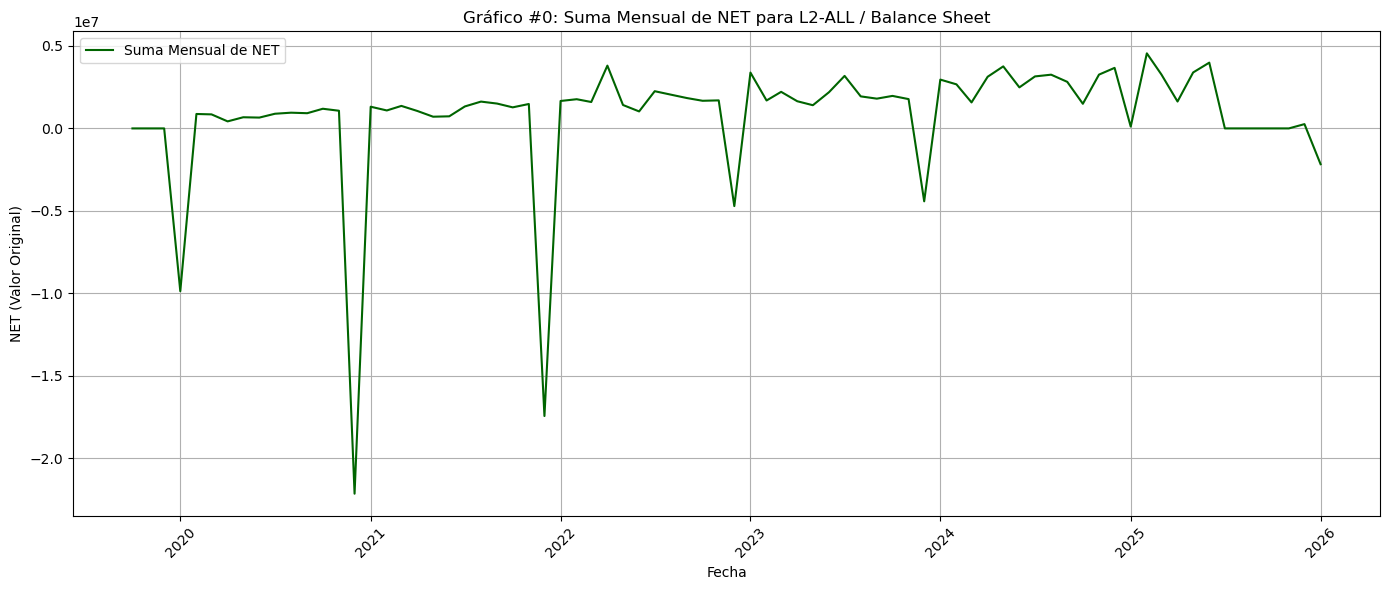

Gráfico 'net_monthly_annual_plot.png' (Serie de Tiempo Histórica) generado.

--- Resumen de Muestras ---
Total de muestras secuenciales: 52. Tren/Val/Test: 31/10/11.

--- 3. Baseline LSTM ---


C:\Users\Diego\anaconda3B\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RMSE Baseline (Prueba): 0.0834


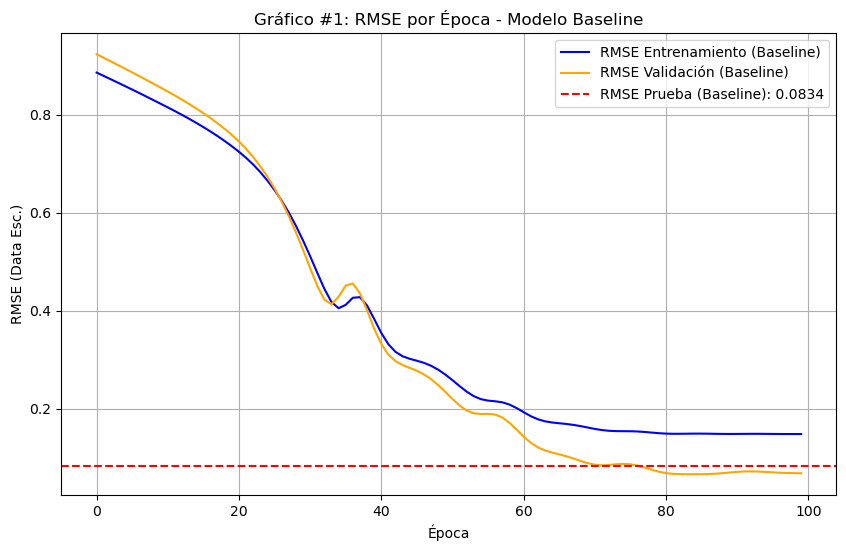

[I 2025-11-27 13:38:21,274] A new study created in memory with name: no-name-9a0b4938-a3ad-447b-a570-7276a00455e1


Gráfico 'baseline_rmse_history.png' generado.

--- 4. Optimización de Hiperparámetros con Optuna ---


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2025-11-27 13:38:36,952] Trial 0 finished with value: 0.06776123493909836 and parameters: {'units': 30, 'learning_rate': 0.002188902981481802, 'batch_size': 32}. Best is trial 0 with value: 0.06776123493909836.
[I 2025-11-27 13:38:53,965] Trial 1 finished with value: 0.7075031995773315 and parameters: {'units': 70, 'learning_rate': 0.00013964731167445096, 'batch_size': 32}. Best is trial 0 with value: 0.06776123493909836.
[I 2025-11-27 13:39:03,914] Trial 2 finished with value: 0.06700305640697479 and parameters: {'units': 90, 'learning_rate': 0.0017922820092025856, 'batch_size': 16}. Best is trial 2 with value: 0.06700305640697479.
[I 2025-11-27 13:39:13,517] Trial 3 finished with value: 0.06772608309984207 and parameters: {'units': 90, 'learning_rate': 0.0011844949084219652, 'batch_size': 16}. Best is trial 2 with value: 0.06700305640697479.
[I 2025-11-27 13:39:22,701] Trial 4 finished with value: 0.07227034121751785 and parameters: {'units': 40, 'learning_rate': 0.002233209247059

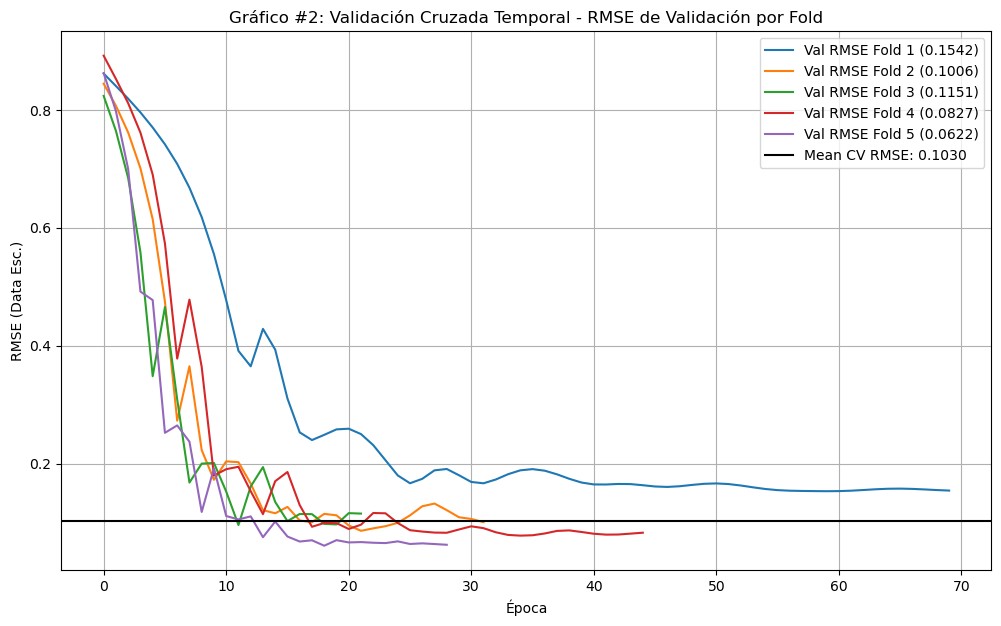

Gráfico 'ts_cross_validation_rmse.png' generado.

--- Tabla de Resultados de la Validación Cruzada ---
╒══════════╤═════════════════╤═════════════════╤═════════════╕
│ Fold     │ Muestras Tren   │ Muestras Test   │   Test RMSE │
╞══════════╪═════════════════╪═════════════════╪═════════════╡
│ 1        │ 11              │ 6               │      0.1542 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 2        │ 17              │ 6               │      0.1006 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 3        │ 23              │ 6               │      0.1151 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 4        │ 29              │ 6               │      0.0827 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 5        │ 35              │ 6               │      0.0622 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ Promedio │ -               │ -               │      0.103  │
╘══════════╧═══

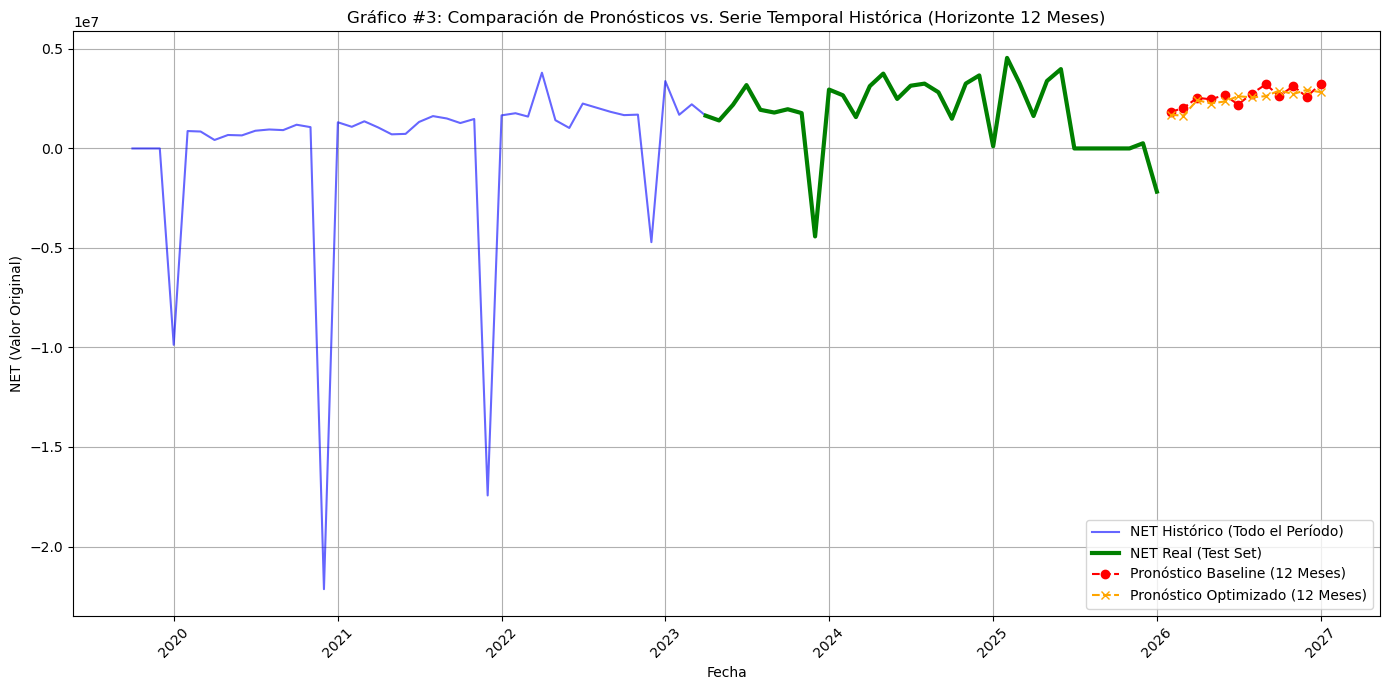

Gráfico 'final_forecast_comparison.png' generado.

--- Tabla de Pronósticos de 12 Meses (NET Original) ---
╒═════════╤════════════╤═══════════════════════╕
│ Mes     │   Baseline │   Optimizado (Optuna) │
╞═════════╪════════════╪═══════════════════════╡
│ 2026-02 │ 1834796.50 │            1694149.62 │
├─────────┼────────────┼───────────────────────┤
│ 2026-03 │ 2031216.25 │            1643980.25 │
├─────────┼────────────┼───────────────────────┤
│ 2026-04 │ 2544988.25 │            2430971.75 │
├─────────┼────────────┼───────────────────────┤
│ 2026-05 │ 2469641.25 │            2257136.50 │
├─────────┼────────────┼───────────────────────┤
│ 2026-06 │ 2682593.00 │            2359152.00 │
├─────────┼────────────┼───────────────────────┤
│ 2026-07 │ 2205581.25 │            2624255.50 │
├─────────┼────────────┼───────────────────────┤
│ 2026-08 │ 2759620.25 │            2567042.75 │
├─────────┼────────────┼───────────────────────┤
│ 2026-09 │ 3219070.50 │            2628622.75 │
├─────────┼

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from math import sqrt
from tabulate import tabulate 

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping

# --- 0. Parámetros Globales ---
FILE_PATH = '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv'
PORTFOLIO_NAME = 'L2-ALL'
DESCTYPE_FILTER_COLUMN = 'DESCTYPE'
DESCTYPE_FILTER_VALUE = 'Balance Sheet' 

LOOK_BACK = 12          # Ventana de entrada (12 meses)
FORECAST_HORIZON = 12   # Pronóstico de 12 meses
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20
N_SPLITS_CV = 5
N_TRIALS_OPTUNA = 15    
BASELINE_EPOCHS = 100
OPTIMIZED_EPOCHS = 100 

# --- 1. Funciones de Modelado y Data Preparation ---

def create_sequences(data, look_back, forecast_horizon):
    """Crea secuencias de entrada (X) y salida (y) para el modelo LSTM."""
    X, y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back : i + look_back + forecast_horizon, 0])
    X_reshaped = np.reshape(np.array(X), (len(X), look_back, 1))
    return X_reshaped, np.array(y)

def build_model(units, learning_rate):
    """Crea un modelo LSTM de Keras con hiperparámetros ajustables."""
    model = Sequential([
        LSTM(units, activation='relu', input_shape=(LOOK_BACK, 1)),
        Dense(FORECAST_HORIZON)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=[RootMeanSquaredError(name='rmse')])
    return model

# --- 2. Carga y Preparación de Datos ---

try:
    df = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{FILE_PATH}'. Asegúrese de que el archivo esté en el directorio correcto.")
    exit()

# Filtrar por PORTFOLIONAME y DESCTYPE
df_filtered = df[
    (df['PORTFOLIONAME'] == PORTFOLIO_NAME) & 
    (df[DESCTYPE_FILTER_COLUMN] == DESCTYPE_FILTER_VALUE)
].copy()

# Verificación de Datos Filtrados
if df_filtered.empty:
    print(f"Error Crítico: No se encontraron registros para PORTFOLIONAME='{PORTFOLIO_NAME}' y {DESCTYPE_FILTER_COLUMN}='{DESCTYPE_FILTER_VALUE}'.")
    exit()

# Crear índice de tiempo y agregar la serie de tiempo (suma mensual de NET)
df_filtered['DATE'] = pd.to_datetime(df_filtered['YEARID'].astype(str) + '-' + df_filtered['MONTHID'].astype(str) + '-01')
df_filtered['NET'] = df_filtered['NET'].fillna(0)
ts_data = df_filtered.groupby('DATE')['NET'].sum().sort_index()

# Escalar la data
data = ts_data.values.reshape(-1, 1)

# Verificación de Longitud de la Serie de Tiempo
min_required_steps = LOOK_BACK + FORECAST_HORIZON
if len(data) < min_required_steps:
    print(f"Error Crítico: La serie de tiempo mensual generada solo tiene {len(data)} puntos.")
    print(f"Se requieren al menos {min_required_steps} ({LOOK_BACK} lookback + {FORECAST_HORIZON} forecast) para crear las primeras secuencias.")
    exit()

# --- 2.5. Gráfico Anual Mensual de NET (Gráfico #0) ---
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data.values, label='Suma Mensual de NET', color='darkgreen')
plt.title(f'Gráfico #0: Suma Mensual de NET para {PORTFOLIO_NAME} / {DESCTYPE_FILTER_VALUE}')
plt.xlabel('Fecha')
plt.ylabel('NET (Valor Original)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('net_monthly_annual_plot.png')
plt.close()
print("Gráfico 'net_monthly_annual_plot.png' (Serie de Tiempo Histórica) generado.")


# Continuar con la preparación para el modelado
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data) 

X, y = create_sequences(scaled_data, LOOK_BACK, FORECAST_HORIZON)

# División 60/20/20 (Secuencial)
total_samples = X.shape[0]
train_end = int(TRAIN_RATIO * total_samples)
val_end = int((TRAIN_RATIO + VAL_RATIO) * total_samples)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f"\n--- Resumen de Muestras ---")
print(f"Total de muestras secuenciales: {total_samples}. Tren/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}.")

# ----------------------------------------------------------------------
## 3. Baseline LSTM (Gráfico #1) 📈
# ----------------------------------------------------------------------

print("\n--- 3. Baseline LSTM ---")
BASELINE_UNITS = 50
BASELINE_LR = 0.001
BASELINE_BATCH_SIZE = 32

baseline_model = build_model(BASELINE_UNITS, BASELINE_LR)
history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=BASELINE_EPOCHS,
    batch_size=BASELINE_BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=0
)

# Evaluación del Baseline
_, baseline_test_rmse = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"RMSE Baseline (Prueba): {baseline_test_rmse:.4f}")

# Gráfico #1: RMSE por Época (Entrenamiento, Validación, Prueba)
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['rmse'], label='RMSE Entrenamiento (Baseline)', color='blue')
plt.plot(history_baseline.history['val_rmse'], label='RMSE Validación (Baseline)', color='orange')
plt.axhline(y=baseline_test_rmse, color='r', linestyle='--', label=f'RMSE Prueba (Baseline): {baseline_test_rmse:.4f}')
plt.title('Gráfico #1: RMSE por Época - Modelo Baseline')
plt.ylabel('RMSE (Data Esc.)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('baseline_rmse_history.png')
plt.close()
print("Gráfico 'baseline_rmse_history.png' generado.")


# ----------------------------------------------------------------------
## 4. Optimización de Hiperparámetros con Optuna (Tabla) 🔎
# ----------------------------------------------------------------------

print("\n--- 4. Optimización de Hiperparámetros con Optuna ---")
X_hpo, y_hpo = X[:val_end], y[:val_end]
hpo_train_size = len(X_train)

def objective(trial):
    """Función objetivo para Optuna: Minimizar el RMSE de validación."""
    units = trial.suggest_int('units', 30, 100, step=10)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    
    model = build_model(units, learning_rate)
    es = EarlyStopping(monitor='val_loss', patience=10, verbose=0, mode='min', restore_best_weights=True)

    history = model.fit(
        X_hpo[:hpo_train_size], y_hpo[:hpo_train_size],
        epochs=OPTIMIZED_EPOCHS,
        batch_size=batch_size,
        validation_data=(X_hpo[hpo_train_size:], y_hpo[hpo_train_size:]),
        callbacks=[es],
        verbose=0
    )
    best_val_rmse = min(history.history['val_rmse'])
    return best_val_rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

BEST_PARAMS = study.best_params
BEST_RMSE_VAL = study.best_value

print("\n--- Tabla de Hiperparámetros Óptimos ---")
# Generar tabla de hiperparámetros
h_table = [
    ["Métrica Objetivo", "Val RMSE"],
    ["Resultado Óptimo", f"{BEST_RMSE_VAL:.4f}"],
    ["Unidades LSTM", BEST_PARAMS['units']],
    ["Tasa de Aprendizaje (LR)", f"{BEST_PARAMS['learning_rate']:.5f}"],
    ["Tamaño del Lote (Batch Size)", BEST_PARAMS['batch_size']]
]
print(tabulate(h_table, headers="firstrow", tablefmt="fancy_grid"))

# ----------------------------------------------------------------------
## 5. Validación Cruzada Temporal (Gráfico #2 y Tabla) 🌐
# ----------------------------------------------------------------------

print("\n--- 5. Validación Cruzada Temporal (5-Fold) ---")
X_cv, y_cv = X[:val_end], y[:val_end]
tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
cv_rmse_scores = []
cv_results_table = []
fold = 1

# Gráfico #2: Resultados de la Validación Cruzada
plt.figure(figsize=(12, 7))

for train_index, test_index in tscv.split(X_cv):
    X_train_cv, X_test_cv = X_cv[train_index], X_cv[test_index]
    y_train_cv, y_test_cv = y_cv[train_index], y_cv[test_index]

    # Entrenar el modelo OPTIMIZADO en cada fold
    cv_model = build_model(BEST_PARAMS['units'], BEST_PARAMS['learning_rate'])
    
    history_cv = cv_model.fit(
        X_train_cv, y_train_cv,
        epochs=OPTIMIZED_EPOCHS,
        batch_size=BEST_PARAMS['batch_size'],
        validation_data=(X_test_cv, y_test_cv),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, verbose=0)],
        verbose=0
    )
    
    # Evaluación en el conjunto de prueba (test) del fold
    _, test_rmse_cv = cv_model.evaluate(X_test_cv, y_test_cv, verbose=0)
    cv_rmse_scores.append(test_rmse_cv)
    cv_results_table.append([fold, len(X_train_cv), len(X_test_cv), f"{test_rmse_cv:.4f}"])
    
    # Graficar la curva de validación de cada fold
    plt.plot(history_cv.history['val_rmse'], label=f'Val RMSE Fold {fold} ({test_rmse_cv:.4f})')
    fold += 1

mean_cv_rmse = np.mean(cv_rmse_scores)
std_cv_rmse = np.std(cv_rmse_scores)

print(f"RMSE Promedio de CV ({N_SPLITS_CV} folds): {mean_cv_rmse:.4f} (+/- {std_cv_rmse:.4f})")

plt.title(f'Gráfico #2: Validación Cruzada Temporal - RMSE de Validación por Fold')
plt.axhline(y=mean_cv_rmse, color='k', linestyle='-', label=f'Mean CV RMSE: {mean_cv_rmse:.4f}')
plt.ylabel('RMSE (Data Esc.)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('ts_cross_validation_rmse.png')
plt.close()
print("Gráfico 'ts_cross_validation_rmse.png' generado.")

# Generar tabla de resultados de CV
print("\n--- Tabla de Resultados de la Validación Cruzada ---")
cv_results_table.append(["Promedio", "-", "-", f"{mean_cv_rmse:.4f}"])
cv_results_table.insert(0, ["Fold", "Muestras Tren", "Muestras Test", "Test RMSE"])
print(tabulate(cv_results_table, headers="firstrow", tablefmt="fancy_grid"))

# ----------------------------------------------------------------------
## 6. Pronóstico Final (Gráfico #3 y Tabla) 🔮
# ----------------------------------------------------------------------

print("\n--- 6. Pronóstico Final (12 Meses) ---")

# Data de entrenamiento final: (Train + Validation)
X_final_train, y_final_train = X[:val_end], y[:val_end]

# 6.1 Entrenamiento y Pronóstico del Modelo Baseline
baseline_final = build_model(BASELINE_UNITS, BASELINE_LR)
baseline_final.fit(X_final_train, y_final_train, epochs=BASELINE_EPOCHS, batch_size=BASELINE_BATCH_SIZE, verbose=0)
last_sequence_baseline = X[val_end-1].reshape(1, LOOK_BACK, 1) 
forecast_baseline_scaled = baseline_final.predict(last_sequence_baseline, verbose=0)[0]


# 6.2 Entrenamiento y Pronóstico del Modelo Optimizado
optimized_final = build_model(BEST_PARAMS['units'], BEST_PARAMS['learning_rate'])
optimized_final.fit(
    X_final_train, y_final_train,
    epochs=OPTIMIZED_EPOCHS,
    batch_size=BEST_PARAMS['batch_size'],
    callbacks=[EarlyStopping(monitor='loss', patience=10, verbose=0)],
    verbose=0
)
last_sequence_optimized = X[val_end-1].reshape(1, LOOK_BACK, 1)
forecast_optimized_scaled = optimized_final.predict(last_sequence_optimized, verbose=0)[0]


# 6.3 Inversión del Escalado para obtener los valores originales
forecast_baseline = scaler.inverse_transform(forecast_baseline_scaled.reshape(-1, 1)).flatten()
forecast_optimized = scaler.inverse_transform(forecast_optimized_scaled.reshape(-1, 1)).flatten()


# 6.4 Gráfico #3: Comparación de Pronósticos
historical_data_original = scaler.inverse_transform(scaled_data).flatten()
dates = ts_data.index
forecast_dates = pd.date_range(start=dates[-1] + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq='MS')
forecast_series_baseline = pd.Series(forecast_baseline, index=forecast_dates)
forecast_series_optimized = pd.Series(forecast_optimized, index=forecast_dates)

plt.figure(figsize=(14, 7))
plt.plot(dates, historical_data_original, label='NET Histórico (Todo el Período)', color='blue', alpha=0.6)

# Resaltar la data de Test (último 20% real)
plt.plot(dates[len(X_train)+len(X_val):], historical_data_original[len(X_train)+len(X_val):], label='NET Real (Test Set)', color='green', linewidth=3)

# Pronósticos
plt.plot(forecast_series_baseline.index, forecast_series_baseline, label='Pronóstico Baseline (12 Meses)', color='red', linestyle='--', marker='o')
plt.plot(forecast_series_optimized.index, forecast_series_optimized, label='Pronóstico Optimizado (12 Meses)', color='orange', linestyle='--', marker='x')

plt.title('Gráfico #3: Comparación de Pronósticos vs. Serie Temporal Histórica (Horizonte 12 Meses)')
plt.xlabel('Fecha')
plt.ylabel('NET (Valor Original)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('final_forecast_comparison.png')
plt.close()
print("Gráfico 'final_forecast_comparison.png' generado.")


# 6.5 Generar tabla de pronósticos
print("\n--- Tabla de Pronósticos de 12 Meses (NET Original) ---")
forecast_table_data = {
    'Mes': [f"{d.strftime('%Y-%m')}" for d in forecast_dates],
    'Baseline': forecast_baseline,
    'Optimizado (Optuna)': forecast_optimized
}
forecast_df = pd.DataFrame(forecast_table_data)
print(tabulate(forecast_df, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=".2f"))

### Pronostico Baseline - (sin Outlaider) (LSTM) / Mejoramiento de Hiperparametros (Optune)

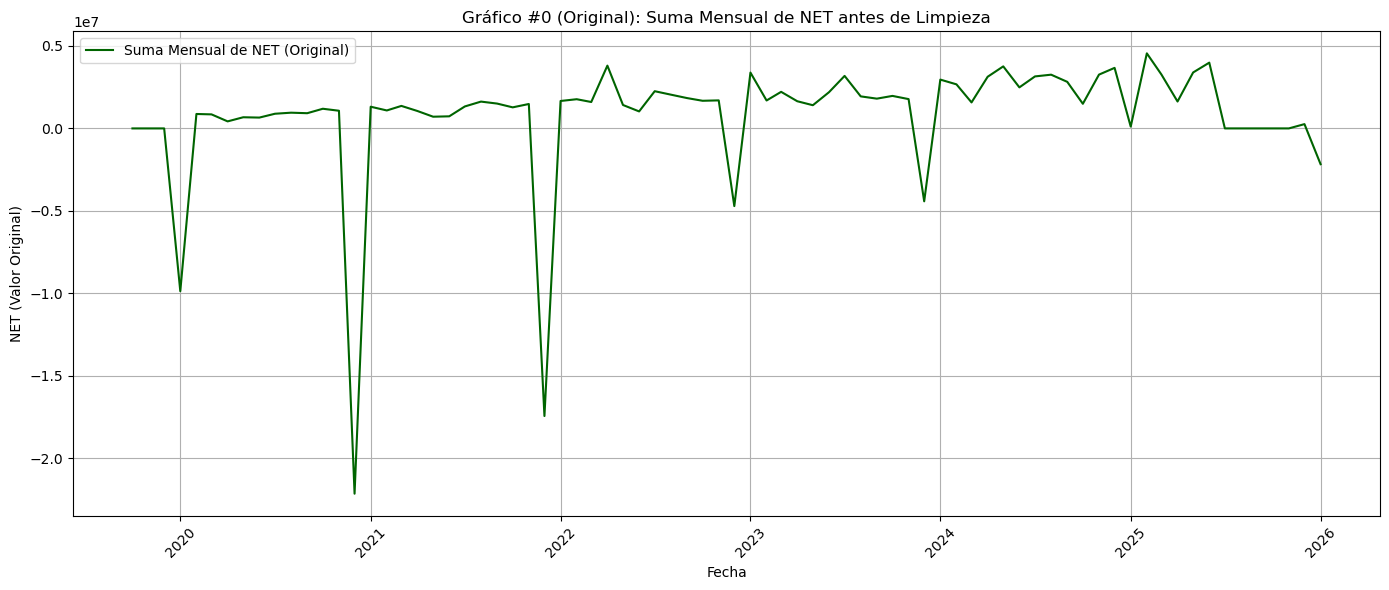

Gráfico 'net_monthly_annual_plot_original.png' (Serie de Tiempo Original) generado.
Data original: 75 meses. Data limpia: 68 meses. Outliers removidos (IQR 1.5): 7


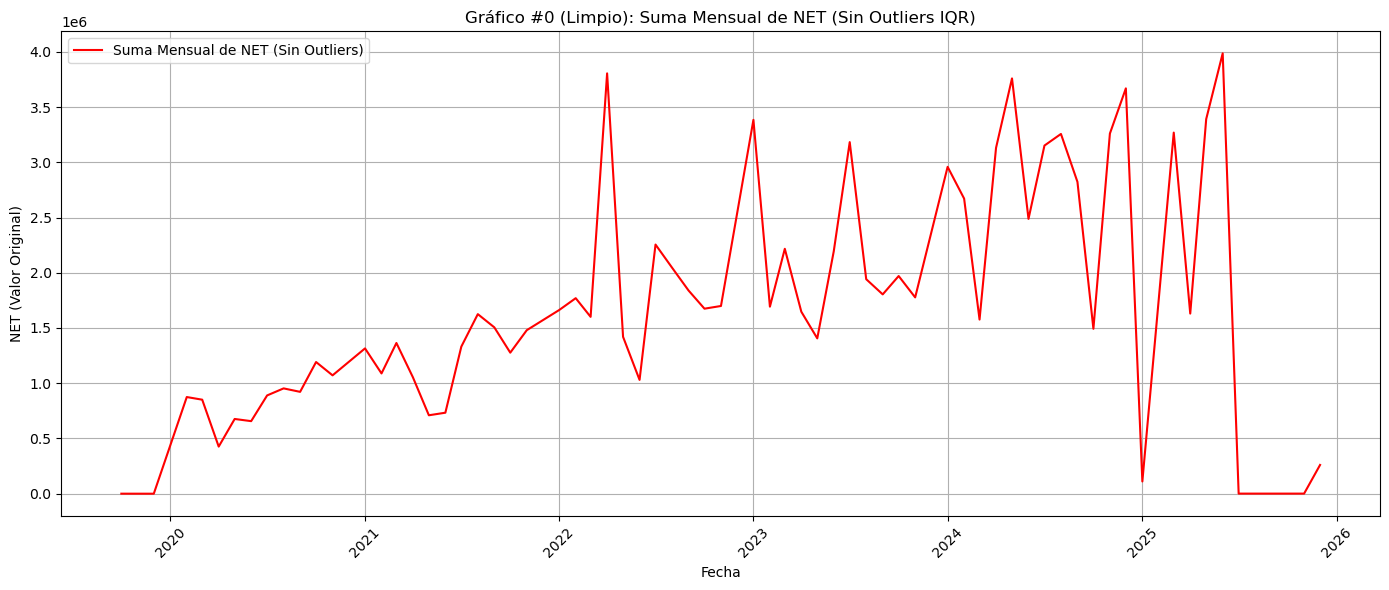

Gráfico 'net_monthly_annual_plot_clean.png' (Serie de Tiempo Limpia) generado.
Muestras para modelado (Cleaned Data): 45. Tren/Val/Test: 27/9/9.

--- 3. Baseline LSTM (Cleaned Data) ---


C:\Users\Diego\anaconda3B\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RMSE Baseline (Prueba): 0.4158


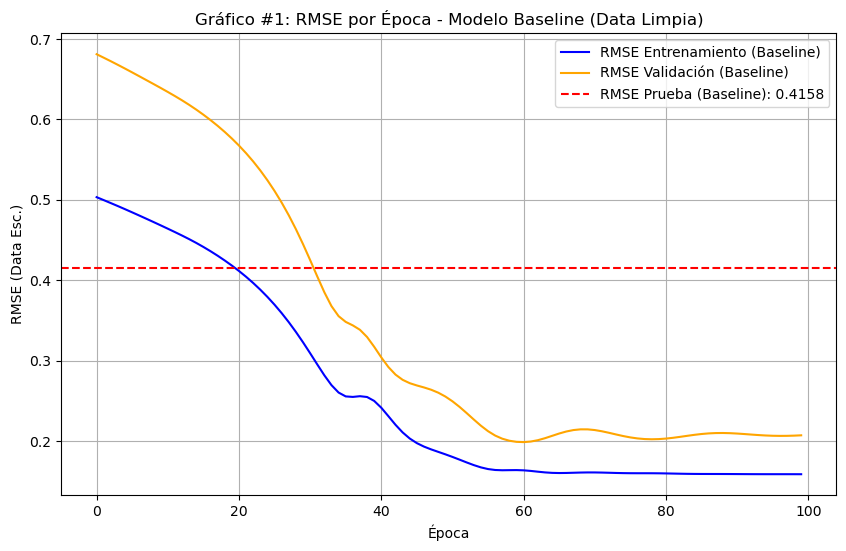

[I 2025-11-27 13:43:10,004] A new study created in memory with name: no-name-5b9244a0-7929-4e6b-acf1-3fa6414280e5


Gráfico 'baseline_rmse_history.png' generado.

--- 4. Optimización de Hiperparámetros con Optuna ---


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2025-11-27 13:43:20,098] Trial 0 finished with value: 0.19907160103321075 and parameters: {'units': 70, 'learning_rate': 0.0007712394376603608, 'batch_size': 16}. Best is trial 0 with value: 0.19907160103321075.
[I 2025-11-27 13:43:27,948] Trial 1 finished with value: 0.19986458122730255 and parameters: {'units': 50, 'learning_rate': 0.0015541758344221526, 'batch_size': 16}. Best is trial 0 with value: 0.19907160103321075.
[I 2025-11-27 13:43:36,803] Trial 2 finished with value: 0.20567303895950317 and parameters: {'units': 30, 'learning_rate': 0.004460861188578677, 'batch_size': 64}. Best is trial 0 with value: 0.19907160103321075.
[I 2025-11-27 13:43:42,778] Trial 3 finished with value: 0.21217350661754608 and parameters: {'units': 100, 'learning_rate': 0.009031835049239895, 'batch_size': 32}. Best is trial 0 with value: 0.19907160103321075.
[I 2025-11-27 13:43:56,017] Trial 4 finished with value: 0.19771836698055267 and parameters: {'units': 70, 'learning_rate': 0.000740642072065

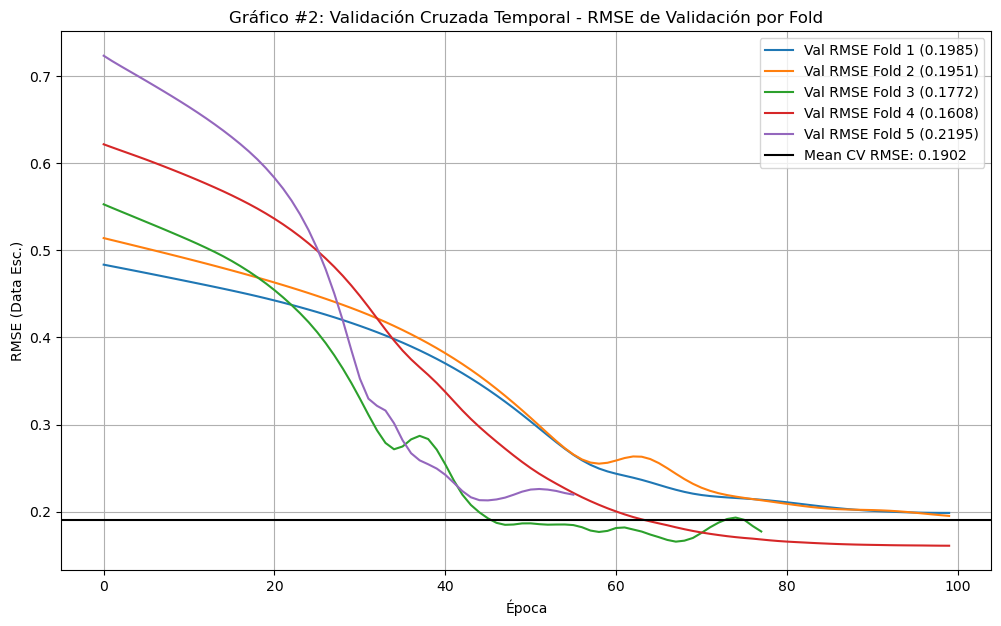

Gráfico 'ts_cross_validation_rmse.png' generado.

--- Tabla de Resultados de la Validación Cruzada ---
╒══════════╤═════════════════╤═════════════════╤═════════════╕
│ Fold     │ Muestras Tren   │ Muestras Test   │   Test RMSE │
╞══════════╪═════════════════╪═════════════════╪═════════════╡
│ 1        │ 6               │ 6               │      0.1985 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 2        │ 12              │ 6               │      0.1951 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 3        │ 18              │ 6               │      0.1772 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 4        │ 24              │ 6               │      0.1608 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 5        │ 30              │ 6               │      0.2195 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ Promedio │ -               │ -               │      0.1902 │
╘══════════╧═══

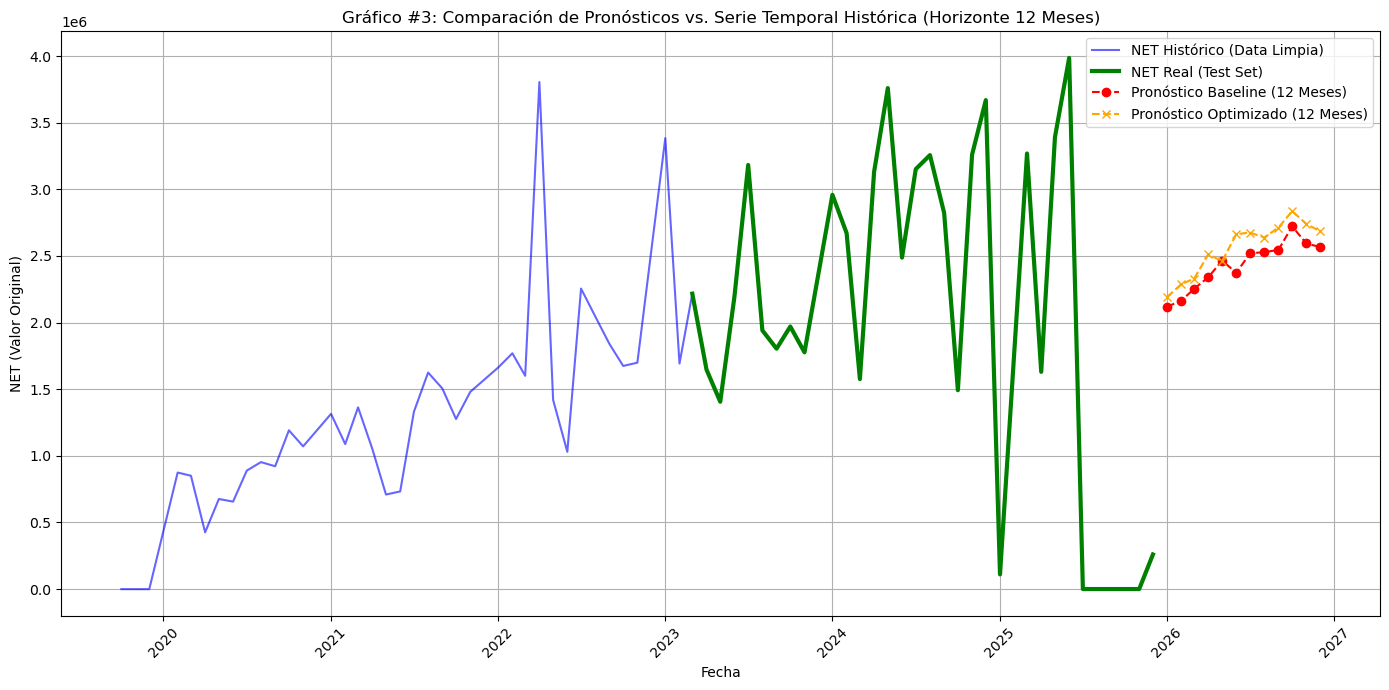

Gráfico 'final_forecast_comparison.png' generado.

--- Tabla de Pronósticos de 12 Meses (NET Original) ---
╒═════════╤════════════╤═══════════════════════╕
│ Mes     │   Baseline │   Optimizado (Optuna) │
╞═════════╪════════════╪═══════════════════════╡
│ 2026-01 │ 2119346.75 │            2191848.50 │
├─────────┼────────────┼───────────────────────┤
│ 2026-02 │ 2164082.00 │            2288364.00 │
├─────────┼────────────┼───────────────────────┤
│ 2026-03 │ 2253693.75 │            2329344.75 │
├─────────┼────────────┼───────────────────────┤
│ 2026-04 │ 2340255.25 │            2512629.75 │
├─────────┼────────────┼───────────────────────┤
│ 2026-05 │ 2465193.50 │            2460396.25 │
├─────────┼────────────┼───────────────────────┤
│ 2026-06 │ 2373502.75 │            2663101.75 │
├─────────┼────────────┼───────────────────────┤
│ 2026-07 │ 2519202.50 │            2675880.00 │
├─────────┼────────────┼───────────────────────┤
│ 2026-08 │ 2528672.75 │            2637803.25 │
├─────────┼

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from math import sqrt
from tabulate import tabulate 

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping

# --- 0. Parámetros Globales ---
FILE_PATH = '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv'
PORTFOLIO_NAME = 'L2-ALL'
DESCTYPE_FILTER_COLUMN = 'DESCTYPE'
DESCTYPE_FILTER_VALUE = 'Balance Sheet' 

LOOK_BACK = 12          
FORECAST_HORIZON = 12   
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20
N_SPLITS_CV = 5
N_TRIALS_OPTUNA = 15    
BASELINE_EPOCHS = 100
OPTIMIZED_EPOCHS = 100 

# --- 1. Funciones de Modelado y Data Preparation ---

def create_sequences(data, look_back, forecast_horizon):
    """Crea secuencias de entrada (X) y salida (y) para el modelo LSTM."""
    X, y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back : i + look_back + forecast_horizon, 0])
    X_reshaped = np.reshape(np.array(X), (len(X), look_back, 1))
    return X_reshaped, np.array(y)

def build_model(units, learning_rate):
    """Crea un modelo LSTM de Keras con hiperparámetros ajustables."""
    model = Sequential([
        LSTM(units, activation='relu', input_shape=(LOOK_BACK, 1)),
        Dense(FORECAST_HORIZON)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=[RootMeanSquaredError(name='rmse')])
    return model

# --- 2. Carga y Preparación de Datos ---

try:
    df = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{FILE_PATH}'. Asegúrese de que el archivo esté en el directorio correcto.")
    exit()

# Filtrar por PORTFOLIONAME y DESCTYPE
df_filtered = df[
    (df['PORTFOLIONAME'] == PORTFOLIO_NAME) & 
    (df[DESCTYPE_FILTER_COLUMN] == DESCTYPE_FILTER_VALUE)
].copy()

if df_filtered.empty:
    print(f"Error Crítico: No se encontraron registros para PORTFOLIONAME='{PORTFOLIO_NAME}' y {DESCTYPE_FILTER_COLUMN}='{DESCTYPE_FILTER_VALUE}'.")
    exit()

# Crear índice de tiempo y agregar la serie de tiempo (suma mensual de NET)
df_filtered['DATE'] = pd.to_datetime(df_filtered['YEARID'].astype(str) + '-' + df_filtered['MONTHID'].astype(str) + '-01')
df_filtered['NET'] = df_filtered['NET'].fillna(0)
ts_data = df_filtered.groupby('DATE')['NET'].sum().sort_index()

# Escalar la data (Temporal para verificación)
data_original = ts_data.values.reshape(-1, 1)


# --- 2.5. Gráfico Anual Mensual de NET (Gráfico #0 - ORIGINAL) ---
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data.values, label='Suma Mensual de NET (Original)', color='darkgreen')
plt.title(f'Gráfico #0 (Original): Suma Mensual de NET antes de Limpieza')
plt.xlabel('Fecha')
plt.ylabel('NET (Valor Original)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('net_monthly_annual_plot_original.png')
plt.close()
print("Gráfico 'net_monthly_annual_plot_original.png' (Serie de Tiempo Original) generado.")


# --- 2.6. Remoción de Outliers (IQR) y Segundo Gráfico ---
Q1 = ts_data.quantile(0.25)
Q3 = ts_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrar la data
ts_data_clean = ts_data[(ts_data >= lower_bound) & (ts_data <= upper_bound)]

outliers_removed = len(ts_data) - len(ts_data_clean)
print(f"Data original: {len(ts_data)} meses. Data limpia: {len(ts_data_clean)} meses. Outliers removidos (IQR 1.5): {outliers_removed}")

if len(ts_data_clean) < min_required_steps:
    print(f"Error Crítico: Después de la limpieza, solo quedan {len(ts_data_clean)} puntos. No hay suficientes para modelar (mínimo {min_required_steps}).")
    exit()

# Gráfico Anual Mensual de NET (Gráfico #0 - LIMPIO)
plt.figure(figsize=(14, 6))
plt.plot(ts_data_clean.index, ts_data_clean.values, label='Suma Mensual de NET (Sin Outliers)', color='red')
plt.title(f'Gráfico #0 (Limpio): Suma Mensual de NET (Sin Outliers IQR)')
plt.xlabel('Fecha')
plt.ylabel('NET (Valor Original)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('net_monthly_annual_plot_clean.png')
plt.close()
print("Gráfico 'net_monthly_annual_plot_clean.png' (Serie de Tiempo Limpia) generado.")


# Usar la data limpia para el modelado
data = ts_data_clean.values.reshape(-1, 1)

# Continuar con la preparación para el modelado
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data) 

X, y = create_sequences(scaled_data, LOOK_BACK, FORECAST_HORIZON)

# División 60/20/20 (Secuencial)
total_samples = X.shape[0]
train_end = int(TRAIN_RATIO * total_samples)
val_end = int((TRAIN_RATIO + VAL_RATIO) * total_samples)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f"Muestras para modelado (Cleaned Data): {total_samples}. Tren/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}.")

# ----------------------------------------------------------------------
## 3. Baseline LSTM (Gráfico #1) 📈
# ----------------------------------------------------------------------

print("\n--- 3. Baseline LSTM (Cleaned Data) ---")
BASELINE_UNITS = 50
BASELINE_LR = 0.001
BASELINE_BATCH_SIZE = 32

baseline_model = build_model(BASELINE_UNITS, BASELINE_LR)
history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=BASELINE_EPOCHS,
    batch_size=BASELINE_BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=0
)

# Evaluación del Baseline
_, baseline_test_rmse = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"RMSE Baseline (Prueba): {baseline_test_rmse:.4f}")

# Gráfico #1: RMSE por Época (Entrenamiento, Validación, Prueba)
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['rmse'], label='RMSE Entrenamiento (Baseline)', color='blue')
plt.plot(history_baseline.history['val_rmse'], label='RMSE Validación (Baseline)', color='orange')
plt.axhline(y=baseline_test_rmse, color='r', linestyle='--', label=f'RMSE Prueba (Baseline): {baseline_test_rmse:.4f}')
plt.title('Gráfico #1: RMSE por Época - Modelo Baseline (Data Limpia)')
plt.ylabel('RMSE (Data Esc.)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('baseline_rmse_history.png')
plt.close()
print("Gráfico 'baseline_rmse_history.png' generado.")


# ----------------------------------------------------------------------
## 4. Optimización de Hiperparámetros con Optuna (Tabla) 🔎
# ----------------------------------------------------------------------

print("\n--- 4. Optimización de Hiperparámetros con Optuna ---")
X_hpo, y_hpo = X[:val_end], y[:val_end]
hpo_train_size = len(X_train)

def objective(trial):
    """Función objetivo para Optuna: Minimizar el RMSE de validación."""
    units = trial.suggest_int('units', 30, 100, step=10)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    
    model = build_model(units, learning_rate)
    es = EarlyStopping(monitor='val_loss', patience=10, verbose=0, mode='min', restore_best_weights=True)

    history = model.fit(
        X_hpo[:hpo_train_size], y_hpo[:hpo_train_size],
        epochs=OPTIMIZED_EPOCHS,
        batch_size=batch_size,
        validation_data=(X_hpo[hpo_train_size:], y_hpo[hpo_train_size:]),
        callbacks=[es],
        verbose=0
    )
    best_val_rmse = min(history.history['val_rmse'])
    return best_val_rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

BEST_PARAMS = study.best_params
BEST_RMSE_VAL = study.best_value

print("\n--- Tabla de Hiperparámetros Óptimos ---")
# Generar tabla de hiperparámetros
h_table = [
    ["Métrica Objetivo", "Val RMSE"],
    ["Resultado Óptimo", f"{BEST_RMSE_VAL:.4f}"],
    ["Unidades LSTM", BEST_PARAMS['units']],
    ["Tasa de Aprendizaje (LR)", f"{BEST_PARAMS['learning_rate']:.5f}"],
    ["Tamaño del Lote (Batch Size)", BEST_PARAMS['batch_size']]
]
print(tabulate(h_table, headers="firstrow", tablefmt="fancy_grid"))

# ----------------------------------------------------------------------
## 5. Validación Cruzada Temporal (Gráfico #2 y Tabla) 🌐
# ----------------------------------------------------------------------

print("\n--- 5. Validación Cruzada Temporal (5-Fold) ---")
X_cv, y_cv = X[:val_end], y[:val_end]
tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
cv_rmse_scores = []
cv_results_table = []
fold = 1

# Gráfico #2: Resultados de la Validación Cruzada
plt.figure(figsize=(12, 7))

for train_index, test_index in tscv.split(X_cv):
    X_train_cv, X_test_cv = X_cv[train_index], X_cv[test_index]
    y_train_cv, y_test_cv = y_cv[train_index], y_cv[test_index]

    # Entrenar el modelo OPTIMIZADO en cada fold
    cv_model = build_model(BEST_PARAMS['units'], BEST_PARAMS['learning_rate'])
    
    history_cv = cv_model.fit(
        X_train_cv, y_train_cv,
        epochs=OPTIMIZED_EPOCHS,
        batch_size=BEST_PARAMS['batch_size'],
        validation_data=(X_test_cv, y_test_cv),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, verbose=0)],
        verbose=0
    )
    
    # Evaluación en el conjunto de prueba (test) del fold
    _, test_rmse_cv = cv_model.evaluate(X_test_cv, y_test_cv, verbose=0)
    cv_rmse_scores.append(test_rmse_cv)
    cv_results_table.append([fold, len(X_train_cv), len(X_test_cv), f"{test_rmse_cv:.4f}"])
    
    # Graficar la curva de validación de cada fold
    plt.plot(history_cv.history['val_rmse'], label=f'Val RMSE Fold {fold} ({test_rmse_cv:.4f})')
    fold += 1

mean_cv_rmse = np.mean(cv_rmse_scores)
std_cv_rmse = np.std(cv_rmse_scores)

print(f"RMSE Promedio de CV ({N_SPLITS_CV} folds): {mean_cv_rmse:.4f} (+/- {std_cv_rmse:.4f})")

plt.title(f'Gráfico #2: Validación Cruzada Temporal - RMSE de Validación por Fold')
plt.axhline(y=mean_cv_rmse, color='k', linestyle='-', label=f'Mean CV RMSE: {mean_cv_rmse:.4f}')
plt.ylabel('RMSE (Data Esc.)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('ts_cross_validation_rmse.png')
plt.close()
print("Gráfico 'ts_cross_validation_rmse.png' generado.")

# Generar tabla de resultados de CV
print("\n--- Tabla de Resultados de la Validación Cruzada ---")
cv_results_table.append(["Promedio", "-", "-", f"{mean_cv_rmse:.4f}"])
cv_results_table.insert(0, ["Fold", "Muestras Tren", "Muestras Test", "Test RMSE"])
print(tabulate(cv_results_table, headers="firstrow", tablefmt="fancy_grid"))

# ----------------------------------------------------------------------
## 6. Pronóstico Final (Gráfico #3 y Tabla) 🔮
# ----------------------------------------------------------------------

print("\n--- 6. Pronóstico Final (12 Meses) ---")

# Data de entrenamiento final: (Train + Validation)
X_final_train, y_final_train = X[:val_end], y[:val_end]

# 6.1 Entrenamiento y Pronóstico del Modelo Baseline
baseline_final = build_model(BASELINE_UNITS, BASELINE_LR)
baseline_final.fit(X_final_train, y_final_train, epochs=BASELINE_EPOCHS, batch_size=BASELINE_BATCH_SIZE, verbose=0)
last_sequence_baseline = X[val_end-1].reshape(1, LOOK_BACK, 1) 
forecast_baseline_scaled = baseline_final.predict(last_sequence_baseline, verbose=0)[0]


# 6.2 Entrenamiento y Pronóstico del Modelo Optimizado
optimized_final = build_model(BEST_PARAMS['units'], BEST_PARAMS['learning_rate'])
optimized_final.fit(
    X_final_train, y_final_train,
    epochs=OPTIMIZED_EPOCHS,
    batch_size=BEST_PARAMS['batch_size'],
    callbacks=[EarlyStopping(monitor='loss', patience=10, verbose=0)],
    verbose=0
)
last_sequence_optimized = X[val_end-1].reshape(1, LOOK_BACK, 1)
forecast_optimized_scaled = optimized_final.predict(last_sequence_optimized, verbose=0)[0]


# 6.3 Inversión del Escalado para obtener los valores originales
forecast_baseline = scaler.inverse_transform(forecast_baseline_scaled.reshape(-1, 1)).flatten()
forecast_optimized = scaler.inverse_transform(forecast_optimized_scaled.reshape(-1, 1)).flatten()


# 6.4 Gráfico #3: Comparación de Pronósticos
historical_data_original = scaler.inverse_transform(scaled_data).flatten()
dates = ts_data_clean.index # Usar índice de la data limpia
forecast_dates = pd.date_range(start=dates[-1] + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq='MS')
forecast_series_baseline = pd.Series(forecast_baseline, index=forecast_dates)
forecast_series_optimized = pd.Series(forecast_optimized, index=forecast_dates)

plt.figure(figsize=(14, 7))
plt.plot(dates, historical_data_original, label='NET Histórico (Data Limpia)', color='blue', alpha=0.6)

# Resaltar la data de Test (último 20% real)
# Nota: Los índices deben ajustarse a la longitud de la data limpia
test_start_index = len(X_train) + len(X_val)
if test_start_index < len(dates):
    plt.plot(dates[test_start_index:], historical_data_original[test_start_index:], label='NET Real (Test Set)', color='green', linewidth=3)


# Pronósticos
plt.plot(forecast_series_baseline.index, forecast_series_baseline, label='Pronóstico Baseline (12 Meses)', color='red', linestyle='--', marker='o')
plt.plot(forecast_series_optimized.index, forecast_series_optimized, label='Pronóstico Optimizado (12 Meses)', color='orange', linestyle='--', marker='x')

plt.title('Gráfico #3: Comparación de Pronósticos vs. Serie Temporal Histórica (Horizonte 12 Meses)')
plt.xlabel('Fecha')
plt.ylabel('NET (Valor Original)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('final_forecast_comparison.png')
plt.close()
print("Gráfico 'final_forecast_comparison.png' generado.")


# 6.5 Generar tabla de pronósticos
print("\n--- Tabla de Pronósticos de 12 Meses (NET Original) ---")
forecast_table_data = {
    'Mes': [f"{d.strftime('%Y-%m')}" for d in forecast_dates],
    'Baseline': forecast_baseline,
    'Optimizado (Optuna)': forecast_optimized
}
forecast_df = pd.DataFrame(forecast_table_data)
print(tabulate(forecast_df, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=".2f"))

### Pronostico Baseline - (sin Outlaider) (LSTM) / Mejoramiento de Hiperparametros (Optune) V2

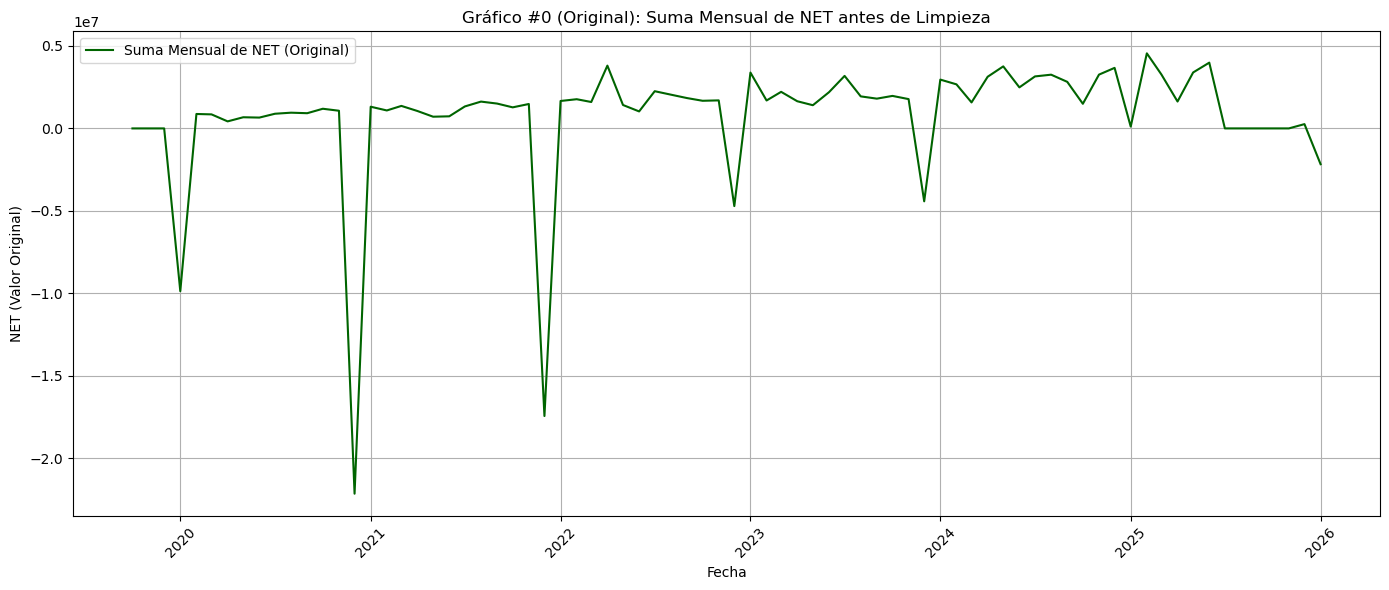

Gráfico 'net_monthly_annual_plot_original.png' generado.
Data original: 75 meses. Data limpia: 68 meses. Outliers removidos: 7


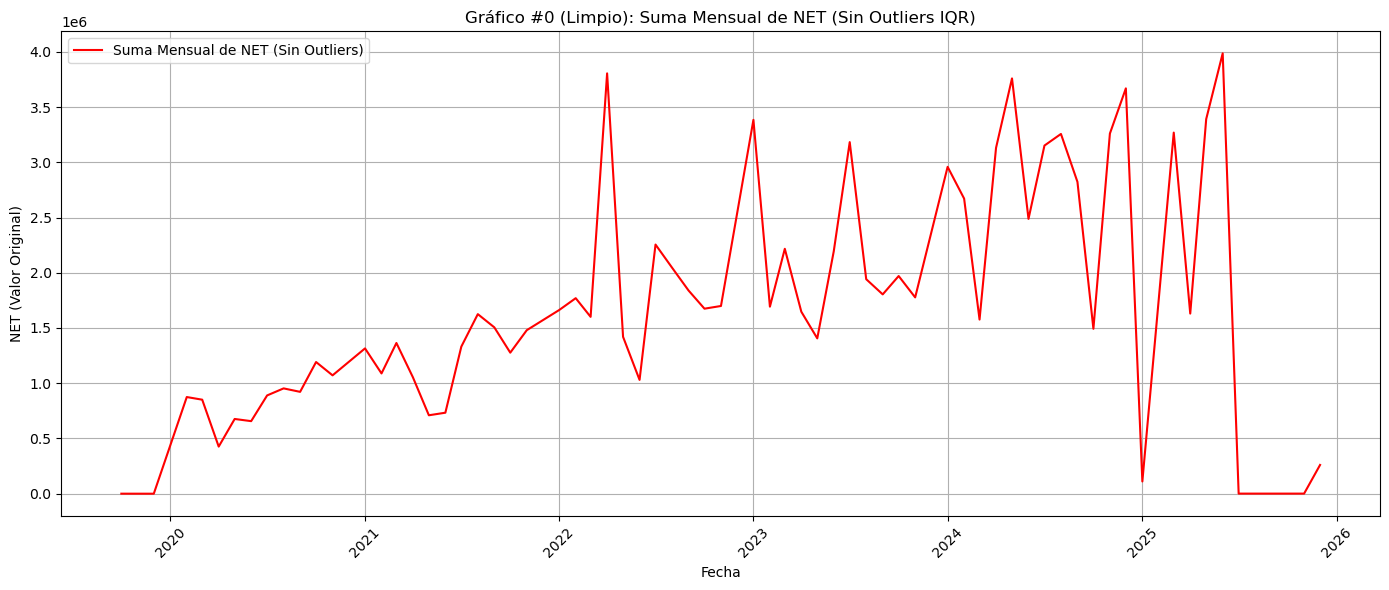

Gráfico 'net_monthly_annual_plot_clean.png' generado.
Muestras para modelado (Cleaned Data): 45. Tren/Val/Test: 27/9/9.

--- 3. Baseline LSTM ---


C:\Users\Diego\anaconda3B\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RMSE LSTM Baseline (Prueba): 0.4198


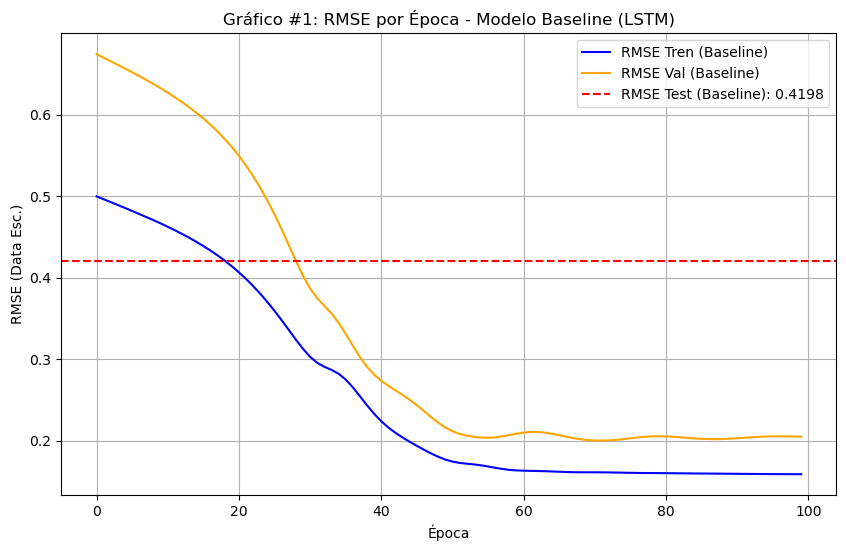

[I 2025-11-27 13:48:45,773] A new study created in memory with name: no-name-97c00fa4-98c1-49ee-9734-ab922f87ff7f


Gráfico 'baseline_lstm_rmse_history.png' generado.

--- 4. Optimización de Hiperparámetros LSTM (Optuna) ---


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2025-11-27 13:48:53,902] Trial 0 finished with value: 0.20993970334529877 and parameters: {'units': 100, 'learning_rate': 0.0012476072860974174, 'batch_size': 64}. Best is trial 0 with value: 0.20993970334529877.
[I 2025-11-27 13:49:09,559] Trial 1 finished with value: 0.20437270402908325 and parameters: {'units': 80, 'learning_rate': 0.00026133080510693516, 'batch_size': 64}. Best is trial 1 with value: 0.20437270402908325.
[I 2025-11-27 13:49:20,753] Trial 2 finished with value: 0.1952776461839676 and parameters: {'units': 40, 'learning_rate': 0.0006972040988259421, 'batch_size': 16}. Best is trial 2 with value: 0.1952776461839676.
[I 2025-11-27 13:49:29,154] Trial 3 finished with value: 0.20114198327064514 and parameters: {'units': 100, 'learning_rate': 0.0036559343289790046, 'batch_size': 32}. Best is trial 2 with value: 0.1952776461839676.
[I 2025-11-27 13:49:41,875] Trial 4 finished with value: 0.20023690164089203 and parameters: {'units': 30, 'learning_rate': 0.00044099177511

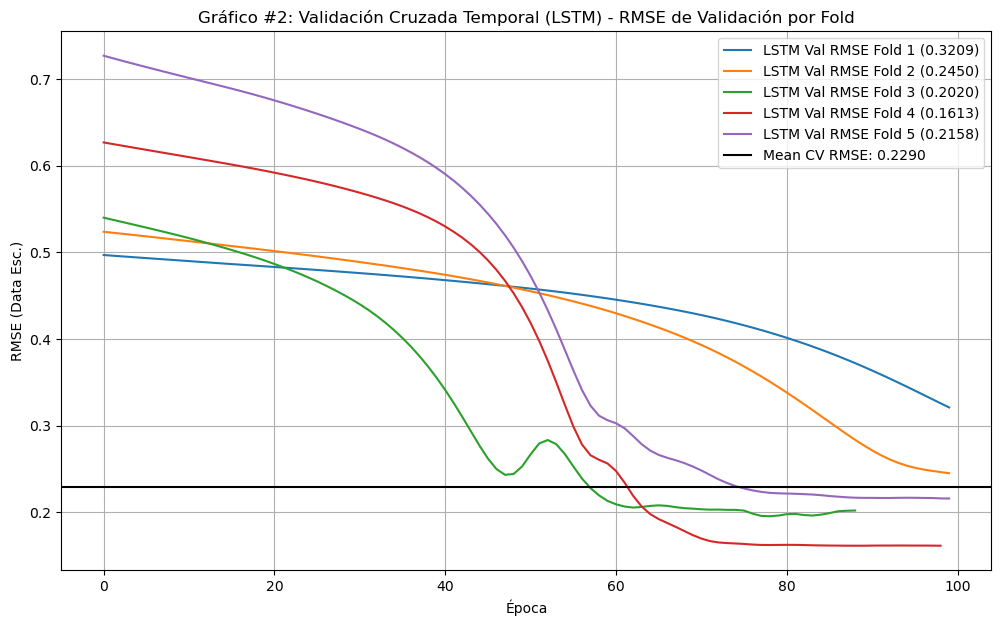

[I 2025-11-27 13:53:10,986] A new study created in memory with name: no-name-830036c4-b26b-4d57-b68e-b427996bdfe5


Gráfico 'ts_cross_validation_lstm_rmse.png' generado.

--- Tabla de Resultados de la Validación Cruzada (LSTM) ---
╒══════════╤═════════════════╤═════════════════╤═════════════╕
│ Fold     │ Muestras Tren   │ Muestras Test   │   Test RMSE │
╞══════════╪═════════════════╪═════════════════╪═════════════╡
│ 1        │ 6               │ 6               │      0.3209 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 2        │ 12              │ 6               │      0.245  │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 3        │ 18              │ 6               │      0.202  │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 4        │ 24              │ 6               │      0.1613 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 5        │ 30              │ 6               │      0.2158 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ Promedio │ -               │ -               │      0.229  │
╘══

  0%|          | 0/15 [00:00<?, ?it/s]

[I 2025-11-27 13:53:17,683] Trial 0 finished with value: 0.19922448694705963 and parameters: {'units': 90, 'learning_rate': 0.0010145480550017658, 'batch_size': 16}. Best is trial 0 with value: 0.19922448694705963.
[I 2025-11-27 13:53:26,189] Trial 1 finished with value: 0.2084275484085083 and parameters: {'units': 40, 'learning_rate': 0.0035724577789389782, 'batch_size': 16}. Best is trial 0 with value: 0.19922448694705963.
[I 2025-11-27 13:53:37,632] Trial 2 finished with value: 0.20155076682567596 and parameters: {'units': 50, 'learning_rate': 0.00044310923095296304, 'batch_size': 16}. Best is trial 0 with value: 0.19922448694705963.
[I 2025-11-27 13:53:43,886] Trial 3 finished with value: 0.21872912347316742 and parameters: {'units': 90, 'learning_rate': 0.002211761486950429, 'batch_size': 64}. Best is trial 0 with value: 0.19922448694705963.
[I 2025-11-27 13:53:52,633] Trial 4 finished with value: 0.2054065465927124 and parameters: {'units': 90, 'learning_rate': 0.0003480874306664

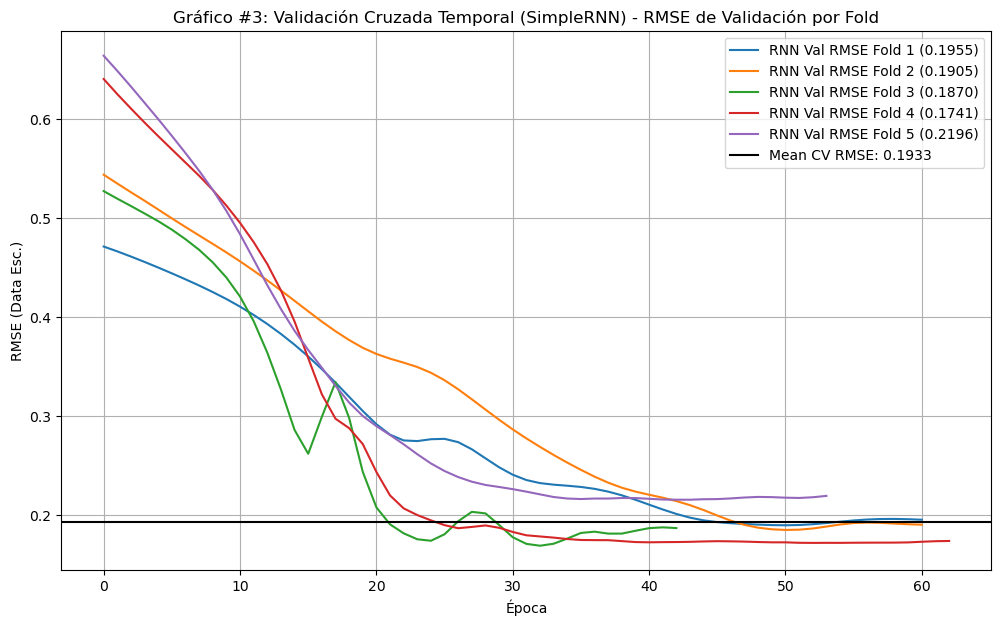

Gráfico 'ts_cross_validation_rnn_rmse.png' generado.

--- Tabla de Resultados de la Validación Cruzada (SimpleRNN) ---
╒══════════╤═════════════════╤═════════════════╤═════════════╕
│ Fold     │ Muestras Tren   │ Muestras Test   │   Test RMSE │
╞══════════╪═════════════════╪═════════════════╪═════════════╡
│ 1        │ 6               │ 6               │      0.1955 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 2        │ 12              │ 6               │      0.1905 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 3        │ 18              │ 6               │      0.187  │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 4        │ 24              │ 6               │      0.1741 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ 5        │ 30              │ 6               │      0.2196 │
├──────────┼─────────────────┼─────────────────┼─────────────┤
│ Promedio │ -               │ -               │      0.1933 │

C:\Users\Diego\anaconda3B\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


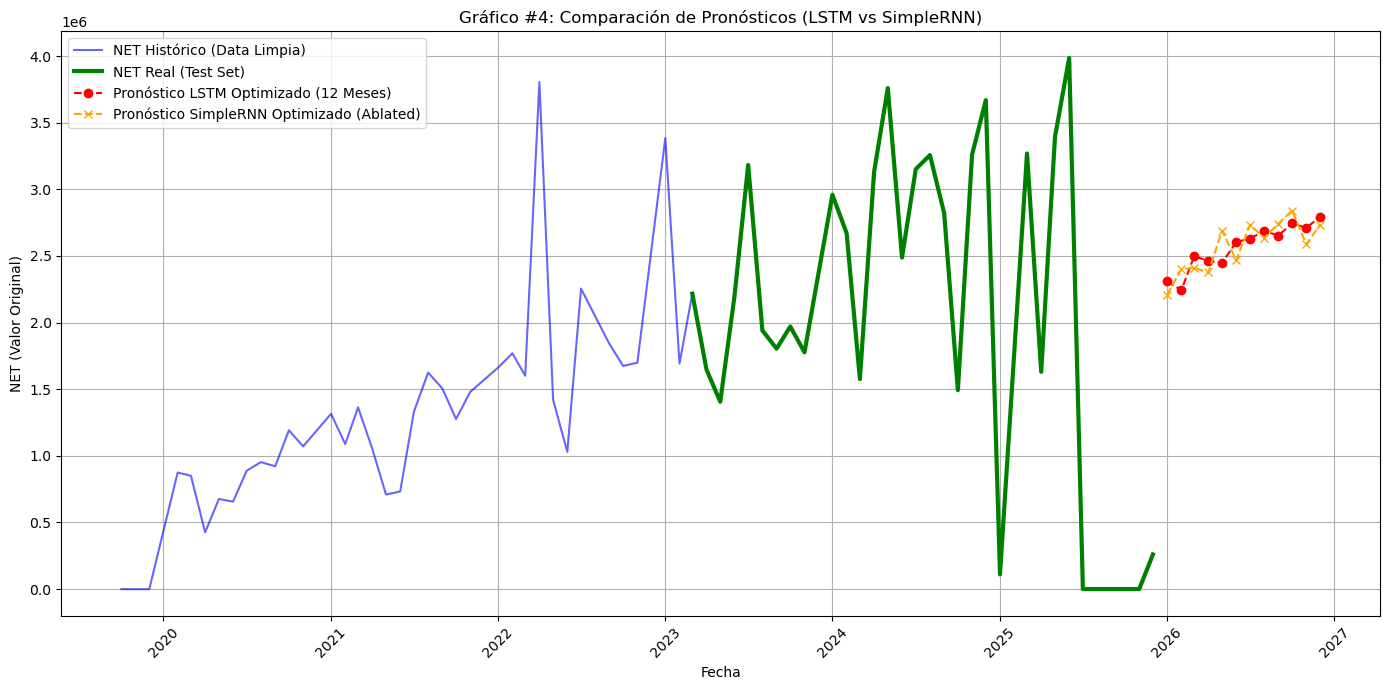

Gráfico 'final_forecast_ablation_comparison.png' generado.

--- Tabla de Pronósticos de 12 Meses (NET Original) ---
╒═════════╤═══════════════════╤══════════════════════════════════╕
│ Mes     │   LSTM Optimizado │   SimpleRNN Optimizado (Ablated) │
╞═════════╪═══════════════════╪══════════════════════════════════╡
│ 2026-01 │        2309206.25 │                       2207759.75 │
├─────────┼───────────────────┼──────────────────────────────────┤
│ 2026-02 │        2243466.75 │                       2401547.50 │
├─────────┼───────────────────┼──────────────────────────────────┤
│ 2026-03 │        2497017.75 │                       2410346.00 │
├─────────┼───────────────────┼──────────────────────────────────┤
│ 2026-04 │        2464797.25 │                       2375864.00 │
├─────────┼───────────────────┼──────────────────────────────────┤
│ 2026-05 │        2447560.25 │                       2689495.75 │
├─────────┼───────────────────┼──────────────────────────────────┤
│ 2026-06 │  

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from math import sqrt
from tabulate import tabulate 

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping

# --- 0. Parámetros Globales ---
FILE_PATH = '../DATA/PROCESSED/PROCESSED_GL_DATA_ALL.csv'
PORTFOLIO_NAME = 'L2-ALL'
DESCTYPE_FILTER_COLUMN = 'DESCTYPE'
DESCTYPE_FILTER_VALUE = 'Balance Sheet' 

LOOK_BACK = 12          
FORECAST_HORIZON = 12   
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20
TEST_RATIO = 0.20
N_SPLITS_CV = 5
N_TRIALS_OPTUNA = 15    
BASELINE_EPOCHS = 100
OPTIMIZED_EPOCHS = 100 

# --- 1. Funciones de Modelado y Data Preparation ---

def create_sequences(data, look_back, forecast_horizon):
    """Crea secuencias de entrada (X) y salida (y) para el modelo LSTM/RNN."""
    X, y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back : i + look_back + forecast_horizon, 0])
    X_reshaped = np.reshape(np.array(X), (len(X), look_back, 1))
    return X_reshaped, np.array(y)

def build_model(units, learning_rate, model_type='LSTM'):
    """Crea un modelo LSTM o SimpleRNN."""
    model = Sequential()
    if model_type == 'LSTM':
        model.add(LSTM(units, activation='relu', input_shape=(LOOK_BACK, 1)))
    elif model_type == 'SimpleRNN':
        model.add(SimpleRNN(units, activation='relu', input_shape=(LOOK_BACK, 1)))
    else:
        raise ValueError("model_type debe ser 'LSTM' o 'SimpleRNN'")

    model.add(Dense(FORECAST_HORIZON))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=[RootMeanSquaredError(name='rmse')])
    return model

# --- 2. Carga, Limpieza y Preparación de Datos ---

try:
    df = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{FILE_PATH}'. Asegúrese de que el archivo esté en el directorio correcto.")
    exit()

# Filtrado inicial
df_filtered = df[
    (df['PORTFOLIONAME'] == PORTFOLIO_NAME) & 
    (df[DESCTYPE_FILTER_COLUMN] == DESCTYPE_FILTER_VALUE)
].copy()

if df_filtered.empty:
    print(f"Error Crítico: No se encontraron registros para los filtros especificados.")
    exit()

df_filtered['DATE'] = pd.to_datetime(df_filtered['YEARID'].astype(str) + '-' + df_filtered['MONTHID'].astype(str) + '-01')
df_filtered['NET'] = df_filtered['NET'].fillna(0)
ts_data = df_filtered.groupby('DATE')['NET'].sum().sort_index()
data_original = ts_data.values.reshape(-1, 1)

# --- 2.1. Gráfico Anual Mensual de NET (Gráfico #0 - ORIGINAL) ---
plt.figure(figsize=(14, 6))
plt.plot(ts_data.index, ts_data.values, label='Suma Mensual de NET (Original)', color='darkgreen')
plt.title(f'Gráfico #0 (Original): Suma Mensual de NET antes de Limpieza')
plt.xlabel('Fecha')
plt.ylabel('NET (Valor Original)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('net_monthly_annual_plot_original.png')
plt.close()
print("Gráfico 'net_monthly_annual_plot_original.png' generado.")


# --- 2.2. Remoción de Outliers (IQR) y Segundo Gráfico ---
Q1 = ts_data.quantile(0.25)
Q3 = ts_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

ts_data_clean = ts_data[(ts_data >= lower_bound) & (ts_data <= upper_bound)]

outliers_removed = len(ts_data) - len(ts_data_clean)
print(f"Data original: {len(ts_data)} meses. Data limpia: {len(ts_data_clean)} meses. Outliers removidos: {outliers_removed}")

min_required_steps = LOOK_BACK + FORECAST_HORIZON
if len(ts_data_clean) < min_required_steps:
    print(f"Error Crítico: Después de la limpieza, solo quedan {len(ts_data_clean)} puntos. No hay suficientes para modelar.")
    exit()

# Gráfico Anual Mensual de NET (Gráfico #0 - LIMPIO)
plt.figure(figsize=(14, 6))
plt.plot(ts_data_clean.index, ts_data_clean.values, label='Suma Mensual de NET (Sin Outliers)', color='red')
plt.title(f'Gráfico #0 (Limpio): Suma Mensual de NET (Sin Outliers IQR)')
plt.xlabel('Fecha')
plt.ylabel('NET (Valor Original)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('net_monthly_annual_plot_clean.png')
plt.close()
print("Gráfico 'net_monthly_annual_plot_clean.png' generado.")


# Preparación de datos limpios para modelado
data = ts_data_clean.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data) 
X, y = create_sequences(scaled_data, LOOK_BACK, FORECAST_HORIZON)

# División 60/20/20 (Secuencial)
total_samples = X.shape[0]
train_end = int(TRAIN_RATIO * total_samples)
val_end = int((TRAIN_RATIO + VAL_RATIO) * total_samples)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f"Muestras para modelado (Cleaned Data): {total_samples}. Tren/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}.")

# ----------------------------------------------------------------------
## 3. Baseline LSTM (Gráfico #1) 📈
# ----------------------------------------------------------------------

print("\n--- 3. Baseline LSTM ---")
BASELINE_UNITS = 50
BASELINE_LR = 0.001
BASELINE_BATCH_SIZE = 32

baseline_model = build_model(BASELINE_UNITS, BASELINE_LR, model_type='LSTM')
history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=BASELINE_EPOCHS,
    batch_size=BASELINE_BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=0
)

# Evaluación del Baseline
_, baseline_test_rmse = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"RMSE LSTM Baseline (Prueba): {baseline_test_rmse:.4f}")

# Gráfico #1: RMSE por Época (Entrenamiento, Validación, Prueba)
plt.figure(figsize=(10, 6))
plt.plot(history_baseline.history['rmse'], label='RMSE Tren (Baseline)', color='blue')
plt.plot(history_baseline.history['val_rmse'], label='RMSE Val (Baseline)', color='orange')
plt.axhline(y=baseline_test_rmse, color='r', linestyle='--', label=f'RMSE Test (Baseline): {baseline_test_rmse:.4f}')
plt.title('Gráfico #1: RMSE por Época - Modelo Baseline (LSTM)')
plt.ylabel('RMSE (Data Esc.)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('baseline_lstm_rmse_history.png')
plt.close()
print("Gráfico 'baseline_lstm_rmse_history.png' generado.")


# ----------------------------------------------------------------------
## 4. Optimización de Hiperparámetros (LSTM) 🔎
# ----------------------------------------------------------------------

print("\n--- 4. Optimización de Hiperparámetros LSTM (Optuna) ---")
X_hpo, y_hpo = X[:val_end], y[:val_end]
hpo_train_size = len(X_train)

def objective_lstm(trial):
    units = trial.suggest_int('units', 30, 100, step=10)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    
    model = build_model(units, learning_rate, model_type='LSTM')
    es = EarlyStopping(monitor='val_loss', patience=10, verbose=0, mode='min', restore_best_weights=True)

    # CORRECCIÓN: Capturar el objeto history
    history = model.fit(
        X_hpo[:hpo_train_size], y_hpo[:hpo_train_size],
        epochs=OPTIMIZED_EPOCHS, batch_size=batch_size,
        validation_data=(X_hpo[hpo_train_size:], y_hpo[hpo_train_size:]),
        callbacks=[es], verbose=0
    )
    return min(history.history['val_rmse'])

study_lstm = optuna.create_study(direction='minimize')
study_lstm.optimize(objective_lstm, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

BEST_PARAMS_LSTM = study_lstm.best_params
BEST_RMSE_VAL_LSTM = study_lstm.best_value

print("\n--- Tabla de Hiperparámetros Óptimos (LSTM) ---")
h_table_lstm = [
    ["Métrica Objetivo", "Val RMSE"],
    ["Resultado Óptimo", f"{BEST_RMSE_VAL_LSTM:.4f}"],
    ["Unidades LSTM", BEST_PARAMS_LSTM['units']],
    ["Tasa de Aprendizaje (LR)", f"{BEST_PARAMS_LSTM['learning_rate']:.5f}"],
    ["Tamaño del Lote (Batch Size)", BEST_PARAMS_LSTM['batch_size']]
]
print(tabulate(h_table_lstm, headers="firstrow", tablefmt="fancy_grid"))

# ----------------------------------------------------------------------
## 5. Validación Cruzada Temporal (LSTM) 🌐
# ----------------------------------------------------------------------

print("\n--- 5. Validación Cruzada Temporal (LSTM 5-Fold) ---")
tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)
cv_rmse_scores_lstm = []
cv_results_table_lstm = []
fold = 1

# Gráfico #2: Resultados de la Validación Cruzada
plt.figure(figsize=(12, 7))

for train_index, test_index in tscv.split(X_hpo):
    X_train_cv, X_test_cv = X_hpo[train_index], X_hpo[test_index]
    y_train_cv, y_test_cv = y_hpo[train_index], y_hpo[test_index]

    cv_model = build_model(BEST_PARAMS_LSTM['units'], BEST_PARAMS_LSTM['learning_rate'], model_type='LSTM')
    
    # CORRECCIÓN: Capturar el objeto history
    history_cv = cv_model.fit(
        X_train_cv, y_train_cv, epochs=OPTIMIZED_EPOCHS,
        batch_size=BEST_PARAMS_LSTM['batch_size'],
        validation_data=(X_test_cv, y_test_cv),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, verbose=0)], verbose=0
    )
    
    _, test_rmse_cv = cv_model.evaluate(X_test_cv, y_test_cv, verbose=0)
    cv_rmse_scores_lstm.append(test_rmse_cv)
    cv_results_table_lstm.append([fold, len(X_train_cv), len(X_test_cv), f"{test_rmse_cv:.4f}"])
    
    plt.plot(history_cv.history['val_rmse'], label=f'LSTM Val RMSE Fold {fold} ({test_rmse_cv:.4f})')
    fold += 1

mean_cv_rmse_lstm = np.mean(cv_rmse_scores_lstm)
std_cv_rmse_lstm = np.std(cv_rmse_scores_lstm)

print(f"RMSE Promedio de CV (LSTM): {mean_cv_rmse_lstm:.4f} (+/- {std_cv_rmse_lstm:.4f})")

plt.title(f'Gráfico #2: Validación Cruzada Temporal (LSTM) - RMSE de Validación por Fold')
plt.axhline(y=mean_cv_rmse_lstm, color='k', linestyle='-', label=f'Mean CV RMSE: {mean_cv_rmse_lstm:.4f}')
plt.ylabel('RMSE (Data Esc.)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('ts_cross_validation_lstm_rmse.png')
plt.close()
print("Gráfico 'ts_cross_validation_lstm_rmse.png' generado.")

# Generar tabla de resultados de CV
print("\n--- Tabla de Resultados de la Validación Cruzada (LSTM) ---")
cv_results_table_lstm.append(["Promedio", "-", "-", f"{mean_cv_rmse_lstm:.4f}"])
cv_results_table_lstm.insert(0, ["Fold", "Muestras Tren", "Muestras Test", "Test RMSE"])
print(tabulate(cv_results_table_lstm, headers="firstrow", tablefmt="fancy_grid"))

# ----------------------------------------------------------------------
## 7. Ablación: SimpleRNN (Re-ejecución HPO, CV, Forecast)
# ----------------------------------------------------------------------

# ----------------------------------------------------------------------
## 8. Optimización de Hiperparámetros (SimpleRNN) 🔎
# ----------------------------------------------------------------------

print("\n--- 8. Optimización de Hiperparámetros SimpleRNN (Optuna) ---")

def objective_rnn(trial):
    units = trial.suggest_int('units', 30, 100, step=10)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    
    model = build_model(units, learning_rate, model_type='SimpleRNN')
    es = EarlyStopping(monitor='val_loss', patience=10, verbose=0, mode='min', restore_best_weights=True)

    # CORRECCIÓN: Capturar el objeto history
    history = model.fit(
        X_hpo[:hpo_train_size], y_hpo[:hpo_train_size],
        epochs=OPTIMIZED_EPOCHS, batch_size=batch_size,
        validation_data=(X_hpo[hpo_train_size:], y_hpo[hpo_train_size:]),
        callbacks=[es], verbose=0
    )
    return min(history.history['val_rmse'])

study_rnn = optuna.create_study(direction='minimize')
study_rnn.optimize(objective_rnn, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

BEST_PARAMS_RNN = study_rnn.best_params
BEST_RMSE_VAL_RNN = study_rnn.best_value

print("\n--- Tabla de Hiperparámetros Óptimos (SimpleRNN) ---")
h_table_rnn = [
    ["Métrica Objetivo", "Val RMSE"],
    ["Resultado Óptimo", f"{BEST_RMSE_VAL_RNN:.4f}"],
    ["Unidades SimpleRNN", BEST_PARAMS_RNN['units']],
    ["Tasa de Aprendizaje (LR)", f"{BEST_PARAMS_RNN['learning_rate']:.5f}"],
    ["Tamaño del Lote (Batch Size)", BEST_PARAMS_RNN['batch_size']]
]
print(tabulate(h_table_rnn, headers="firstrow", tablefmt="fancy_grid"))


# ----------------------------------------------------------------------
## 9. Validación Cruzada Temporal (SimpleRNN) 🌐
# ----------------------------------------------------------------------

print("\n--- 9. Validación Cruzada Temporal (SimpleRNN 5-Fold) ---")
cv_rmse_scores_rnn = []
cv_results_table_rnn = []
fold = 1

# Gráfico #3: Resultados de la Validación Cruzada RNN
plt.figure(figsize=(12, 7))

for train_index, test_index in tscv.split(X_hpo):
    X_train_cv, X_test_cv = X_hpo[train_index], X_hpo[test_index]
    y_train_cv, y_test_cv = y_hpo[train_index], y_hpo[test_index]

    cv_model = build_model(BEST_PARAMS_RNN['units'], BEST_PARAMS_RNN['learning_rate'], model_type='SimpleRNN')
    
    # CORRECCIÓN: Capturar el objeto history
    history_cv = cv_model.fit(
        X_train_cv, y_train_cv, epochs=OPTIMIZED_EPOCHS,
        batch_size=BEST_PARAMS_RNN['batch_size'],
        validation_data=(X_test_cv, y_test_cv),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, verbose=0)], verbose=0
    )
    
    _, test_rmse_cv = cv_model.evaluate(X_test_cv, y_test_cv, verbose=0)
    cv_rmse_scores_rnn.append(test_rmse_cv)
    cv_results_table_rnn.append([fold, len(X_train_cv), len(X_test_cv), f"{test_rmse_cv:.4f}"])
    
    plt.plot(history_cv.history['val_rmse'], label=f'RNN Val RMSE Fold {fold} ({test_rmse_cv:.4f})')
    fold += 1

mean_cv_rmse_rnn = np.mean(cv_rmse_scores_rnn)
std_cv_rmse_rnn = np.std(cv_rmse_scores_rnn)

print(f"RMSE Promedio de CV (SimpleRNN): {mean_cv_rmse_rnn:.4f} (+/- {std_cv_rmse_rnn:.4f})")

plt.title(f'Gráfico #3: Validación Cruzada Temporal (SimpleRNN) - RMSE de Validación por Fold')
plt.axhline(y=mean_cv_rmse_rnn, color='k', linestyle='-', label=f'Mean CV RMSE: {mean_cv_rmse_rnn:.4f}')
plt.ylabel('RMSE (Data Esc.)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('ts_cross_validation_rnn_rmse.png')
plt.close()
print("Gráfico 'ts_cross_validation_rnn_rmse.png' generado.")

# Generar tabla de resultados de CV
print("\n--- Tabla de Resultados de la Validación Cruzada (SimpleRNN) ---")
cv_results_table_rnn.append(["Promedio", "-", "-", f"{mean_cv_rmse_rnn:.4f}"])
cv_results_table_rnn.insert(0, ["Fold", "Muestras Tren", "Muestras Test", "Test RMSE"])
print(tabulate(cv_results_table_rnn, headers="firstrow", tablefmt="fancy_grid"))

# ----------------------------------------------------------------------
## 10. Pronóstico Final y Comparación (Gráfico #4 y Tabla) 🔮
# ----------------------------------------------------------------------

print("\n--- 10. Pronóstico Final (12 Meses) y Comparación ---")

# Data de entrenamiento final: (Train + Validation)
X_final_train, y_final_train = X[:val_end], y[:val_end]
last_sequence = X[val_end-1].reshape(1, LOOK_BACK, 1)

# 10.1 Pronóstico Modelo Optimizado LSTM
lstm_final = build_model(BEST_PARAMS_LSTM['units'], BEST_PARAMS_LSTM['learning_rate'], model_type='LSTM')
# CORRECCIÓN: Capturar history aunque no se use
history_lstm_final = lstm_final.fit(X_final_train, y_final_train, epochs=OPTIMIZED_EPOCHS, batch_size=BEST_PARAMS_LSTM['batch_size'], verbose=0, 
               callbacks=[EarlyStopping(monitor='loss', patience=10, verbose=0)])
forecast_lstm_scaled = lstm_final.predict(last_sequence, verbose=0)[0]
forecast_lstm = scaler.inverse_transform(forecast_lstm_scaled.reshape(-1, 1)).flatten()


# 10.2 Pronóstico Modelo Optimizado SimpleRNN (Ablated)
rnn_final = build_model(BEST_PARAMS_RNN['units'], BEST_PARAMS_RNN['learning_rate'], model_type='SimpleRNN')
# CORRECCIÓN: Capturar history aunque no se use
history_rnn_final = rnn_final.fit(X_final_train, y_final_train, epochs=OPTIMIZED_EPOCHS, batch_size=BEST_PARAMS_RNN['batch_size'], verbose=0,
               callbacks=[EarlyStopping(monitor='loss', patience=10, verbose=0)])
forecast_rnn_scaled = rnn_final.predict(last_sequence, verbose=0)[0]
forecast_rnn = scaler.inverse_transform(forecast_rnn_scaled.reshape(-1, 1)).flatten()


# 10.3 Gráfico #4: Comparación de Pronósticos
historical_data_original = scaler.inverse_transform(scaled_data).flatten()
dates = ts_data_clean.index
forecast_dates = pd.date_range(start=dates[-1] + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq='MS')
forecast_series_lstm = pd.Series(forecast_lstm, index=forecast_dates)
forecast_series_rnn = pd.Series(forecast_rnn, index=forecast_dates)

plt.figure(figsize=(14, 7))
plt.plot(dates, historical_data_original, label='NET Histórico (Data Limpia)', color='blue', alpha=0.6)

# Resaltar la data de Test
test_start_index = len(X_train) + len(X_val)
if test_start_index < len(dates):
    plt.plot(dates[test_start_index:], historical_data_original[test_start_index:], label='NET Real (Test Set)', color='green', linewidth=3)

# Pronósticos
plt.plot(forecast_series_lstm.index, forecast_series_lstm, label='Pronóstico LSTM Optimizado (12 Meses)', color='red', linestyle='--', marker='o')
plt.plot(forecast_series_rnn.index, forecast_series_rnn, label='Pronóstico SimpleRNN Optimizado (Ablated)', color='orange', linestyle='--', marker='x')

plt.title('Gráfico #4: Comparación de Pronósticos (LSTM vs SimpleRNN)')
plt.xlabel('Fecha')
plt.ylabel('NET (Valor Original)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('final_forecast_ablation_comparison.png')
plt.close()
print("Gráfico 'final_forecast_ablation_comparison.png' generado.")


# 10.4 Generar tabla de pronósticos
print("\n--- Tabla de Pronósticos de 12 Meses (NET Original) ---")
forecast_table_data = {
    'Mes': [f"{d.strftime('%Y-%m')}" for d in forecast_dates],
    'LSTM Optimizado': forecast_lstm,
    'SimpleRNN Optimizado (Ablated)': forecast_rnn
}
forecast_df = pd.DataFrame(forecast_table_data)
print(tabulate(forecast_df, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=".2f"))